In [1]:
import pandas as pd
df_filtered = pd.read_pickle("scRNA_filtered_genes.pkl")

Analysis of IL1b and CD36 expression in single cells and clonal and mixed populations (Fig. S13AB).

Single-cell RNA-seq data were analyzed from a dataset comprising multiple clonal and mixed macrophage populations. The expression matrix consisted of genes as rows and individual cells as columns. Cells were annotated by sample identity based on column labels (JM01–JM12), and samples were grouped into predefined clonal categories. Genes with low expression were filtered by requiring detection in at least a minimum number of cells (≥3 cells or ≥1% of cells, whichever was greater).

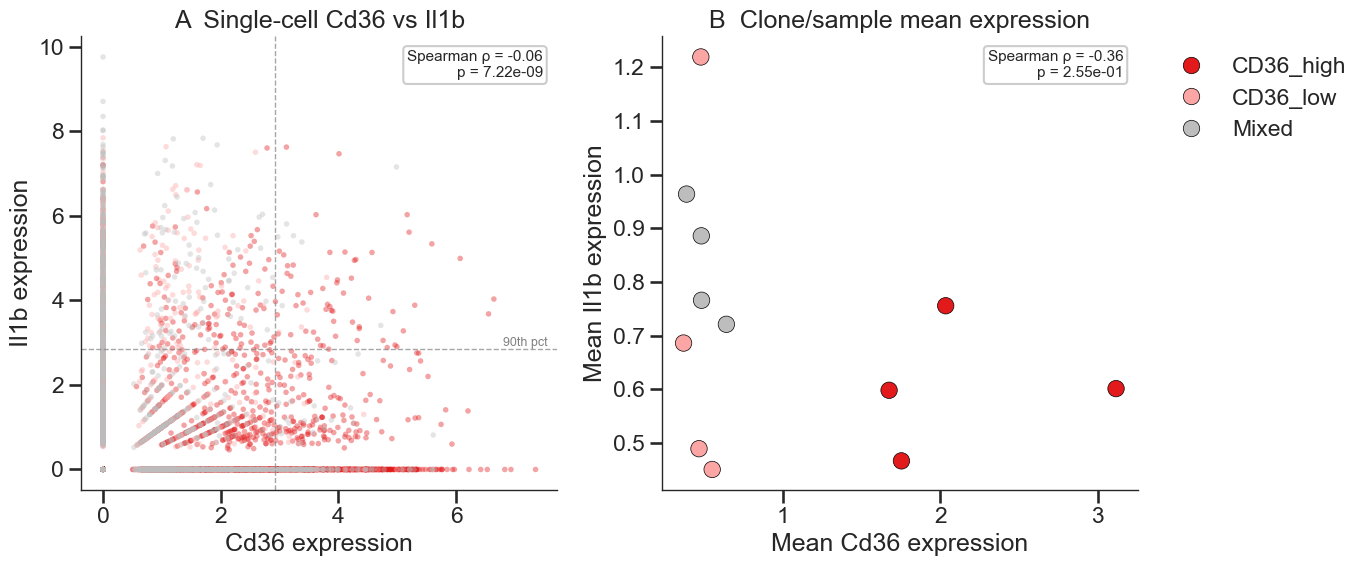

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import matplotlib as mpl

# =========================================================
# SVG / INKSCAPE SETTINGS
# =========================================================
mpl.rcParams["svg.fonttype"] = "none"       # keep text editable
mpl.rcParams["font.family"] = "DejaVu Sans" # safe font for Inkscape

# =========================================================
# INPUTS
# =========================================================
df = df_filtered.copy()

cd36_gene = "Cd36"
il1b_gene = "Il1b"

high_clones = ["JM01", "JM03", "JM04", "JM05"]
low_clones  = ["JM02", "JM06", "JM07", "JM08"]
mixed_clones = ["JM09", "JM10", "JM11", "JM12"]

group_order = ["CD36_high", "CD36_low", "Mixed"]
palette = {
    "CD36_high": "#E31A1C",
    "CD36_low":  "#FCA5A5",
    "Mixed":     "#BDBDBD"
}


# =========================================================
# STYLE
# =========================================================
sns.set(style="ticks", context="talk")

# =========================================================
# DATA EXTRACTION
# =========================================================
sample_mask = df.columns.astype(str).str.startswith("JM")
sample_names = df.columns[sample_mask].to_numpy()

cd36_vals = pd.to_numeric(
    df.loc[df["Symbol"] == cd36_gene, sample_mask].iloc[0],
    errors="coerce"
).to_numpy()

il1b_vals = pd.to_numeric(
    df.loc[df["Symbol"] == il1b_gene, sample_mask].iloc[0],
    errors="coerce"
).to_numpy()

# =========================================================
# BUILD CELL TABLE
# =========================================================
plot_df = pd.DataFrame({
    "sample": sample_names,
    "Cd36": cd36_vals,
    "Il1b": il1b_vals
}).dropna()

def assign_group(sample):
    if sample in high_clones:
        return "CD36_high"
    elif sample in low_clones:
        return "CD36_low"
    elif sample in mixed_clones:
        return "Mixed"
    return np.nan

plot_df["CD36_group"] = plot_df["sample"].apply(assign_group)
plot_df = plot_df.dropna()

# =========================================================
# SAMPLE MEANS
# =========================================================
sample_means = (
    plot_df.groupby("sample", as_index=False)[["Cd36", "Il1b"]]
    .mean()
)
sample_means["CD36_group"] = sample_means["sample"].apply(assign_group)

# =========================================================
# CORRELATIONS
# =========================================================
rho_all, p_all = spearmanr(plot_df["Cd36"], plot_df["Il1b"])
rho_sample, p_sample = spearmanr(sample_means["Cd36"], sample_means["Il1b"])

# =========================================================
# THRESHOLDS
# =========================================================
cd36_thr = np.percentile(plot_df["Cd36"], 90)
il1b_thr = np.percentile(plot_df["Il1b"], 90)

# =========================================================
# FIGURE
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---------------- Panel A ----------------
ax = axes[0]

sns.scatterplot(
    data=plot_df,
    x="Cd36",
    y="Il1b",
    hue="CD36_group",
    palette=palette,
    alpha=0.4,
    s=16,
    linewidth=0,
    legend=False,
    ax=ax
)

# threshold lines
ax.axvline(cd36_thr, ls="--", lw=1, color="grey", alpha=0.7)
ax.axhline(il1b_thr, ls="--", lw=1, color="grey", alpha=0.7)

# horizontal label only
ax.text(
    ax.get_xlim()[1]*0.98,
    il1b_thr,
    "90th pct",
    ha="right",
    va="bottom",
    fontsize=9,
    color="grey"
)

# correlation box (top right)
ax.text(
    0.97, 0.97,
    f"Spearman ρ = {rho_all:.2f}\np = {p_all:.2e}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.8")
)

ax.set_title("A  Single-cell Cd36 vs Il1b")
ax.set_xlabel("Cd36 expression")
ax.set_ylabel("Il1b expression")
ax.grid(False)

# ---------------- Panel B ----------------
ax = axes[1]

sns.scatterplot(
    data=sample_means,
    x="Cd36",
    y="Il1b",
    hue="CD36_group",
    palette=palette,
    s=140,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

# correlation box
ax.text(
    0.97, 0.97,
    f"Spearman ρ = {rho_sample:.2f}\np = {p_sample:.2e}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.8")
)

# legend outside
ax.legend(
    title="",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.set_title("B  Clone/sample mean expression")
ax.set_xlabel("Mean Cd36 expression")
ax.set_ylabel("Mean Il1b expression")
ax.grid(False)

# =========================================================
# FINAL CLEANUP
# =========================================================
for ax in axes:
    ax.spines["left"].set_linewidth(1)
    ax.spines["bottom"].set_linewidth(1)

sns.despine()
plt.tight_layout()

# =========================================================
# SAVE FOR INKSCAPE
# =========================================================
fig.savefig("Fig_CD36_IL1B_panels_A_B.svg", bbox_inches="tight")

# optional backup
# fig.savefig("Fig_CD36_IL1B_panels_A_B.pdf", bbox_inches="tight")
# fig.savefig("Fig_CD36_IL1B_panels_A_B.png", dpi=300, bbox_inches="tight")

plt.show()

# Latent variable analysis

This analysis aimed to determine whether the relationship between Cd36 and Il1b reflects broader transcriptional programmes rather than isolated gene expression differences. Starting from a pre-filtered and log-normalized single-cell RNA-seq dataset comprising 9,166 cells and 10,631 genes, genes expressed in fewer than 1% of cells were assessed, although no additional filtering was required. The analysis then focused on the 2,000 most variable genes, while ensuring inclusion of Cd36 and Il1b, and constructed a cell-by-gene expression matrix without further normalization, as the data were already log-transformed upstream.

Non-negative matrix factorization (NMF) was applied to decompose the data into five latent transcriptional programmes. Two programmes were identified as most strongly associated with Cd36 and Il1b based on gene loadings. The Cd36-associated programme was characterized by genes such as Gpnmb, Trem2, Igf1, Ctsk, and Hmox1, consistent with a tissue-remodelling or lipid-associated macrophage state. In contrast, the Il1b-associated programme was defined by genes including Acod1, Tnf, Nlrp3, Cxcl2, and Nfkbia, representing a canonical inflammatory programme.

(10631, 9166)
           sample CD36_group
cell_id                     
cell_00000   JM01  CD36_high
cell_00001   JM01  CD36_high
cell_00002   JM01  CD36_high
cell_00003   JM01  CD36_high
cell_00004   JM01  CD36_high
Min cells threshold: 91
Genes before filtering: 10631
Genes after filtering: 10631
Genes removed: 0 (0.00%)
Matrix for NMF: 2000 genes x 9166 cells

Cd36-like programme: Program_3
Il1b-like programme: Program_1

Top genes in Program_3:
Symbol
Gpnmb       9.200948
Ctsk        8.977879
Malat1      7.956017
Ccl4        7.799183
Ccl2        7.700045
Ccl3        7.374522
Lyz2        7.351110
Hmox1       7.192869
Spink5      6.823951
Lilr4b      6.750785
Lilrb4a     6.733369
Tnfrsf1b    6.715803
Plk2        6.637076
Metrnl      6.569335
Igf1        6.560620
Dlgap2      6.550405
Nav1        6.410219
Mtss1       6.232318
Alcam       6.167694
Pmp22       6.060885
Acod1       5.916538
Lat2        5.828021
Vim         5.824994
Gdf15       5.817166
Clec4e      5.802914
Fam20c      5.7

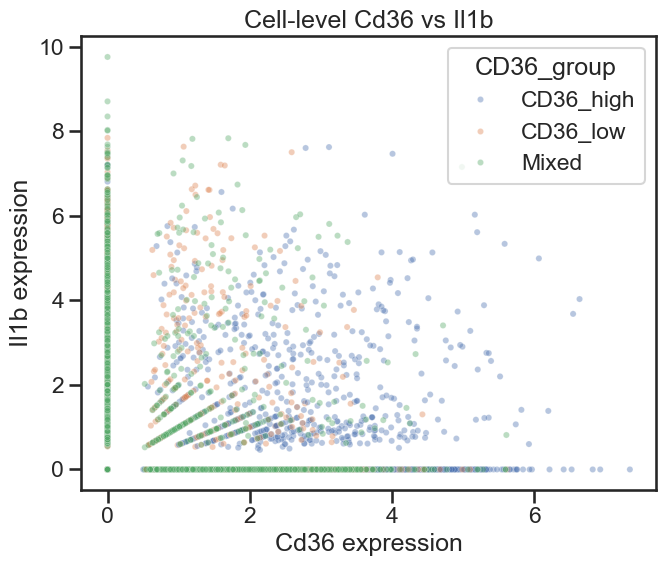

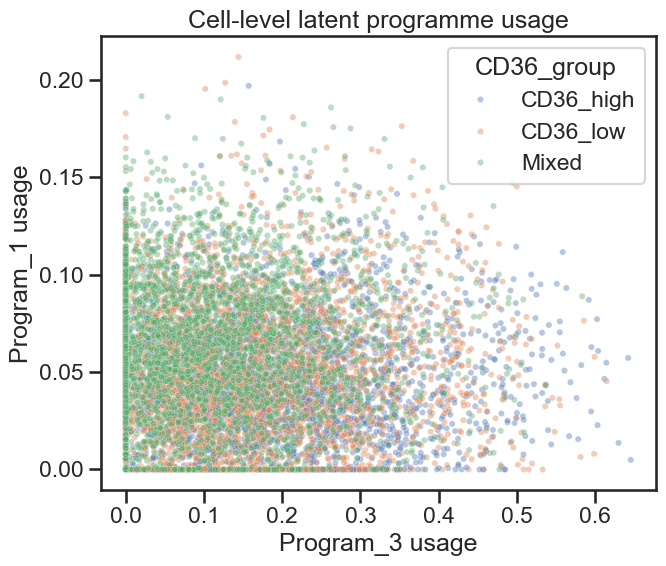

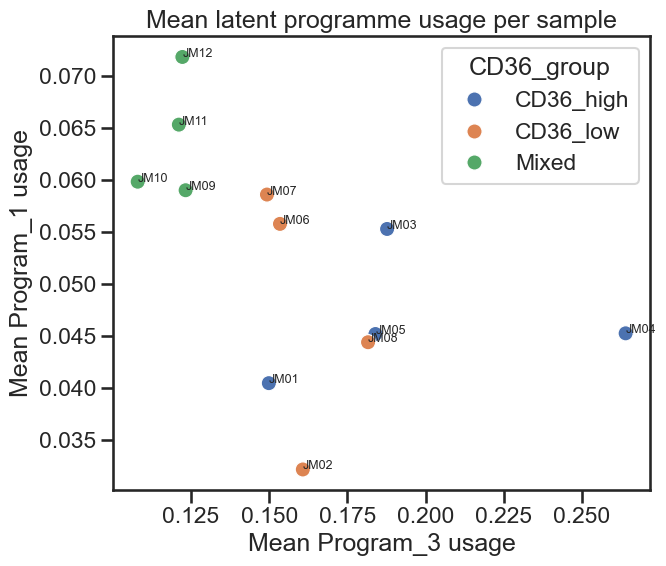

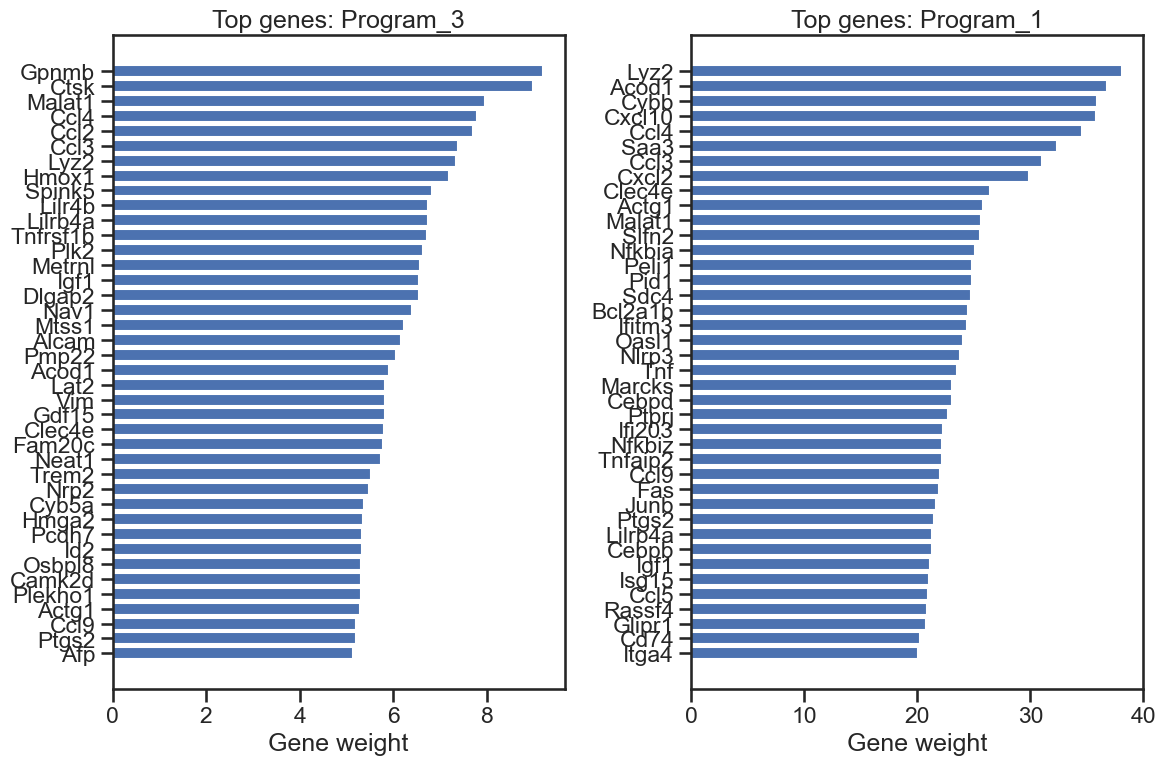

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from sklearn.decomposition import NMF

# =========================
# INPUTS
# =========================
df = df_filtered.copy()

cd36_gene = "Cd36"
il1b_gene = "Il1b"

high_clones = ["JM01", "JM03", "JM04", "JM05"]
low_clones  = ["JM02", "JM06", "JM07", "JM08"]
mixed_clones = ["JM09", "JM10", "JM11", "JM12"]

n_top_variable_genes = 2000
nmf_k = 6
random_state = 0
max_iter = 1000

# =========================
# CHECKS
# =========================
if "Symbol" not in df.columns:
    raise ValueError("Column 'Symbol' not found.")

sample_mask = df.columns.astype(str).str.startswith("JM")
if sample_mask.sum() == 0:
    raise ValueError("No JM columns found.")

# per-cell sample labels; duplicates are expected
sample_labels = df.columns[sample_mask].astype(str).to_numpy()

# unique internal cell IDs
cell_ids = [f"cell_{i:05d}" for i in range(len(sample_labels))]

# =========================
# BUILD EXPRESSION MATRIX SAFELY
# use iloc, not loc
# =========================
symbol_idx = df.columns.get_loc("Symbol")
jm_idx = np.where(sample_mask)[0]
keep_idx = np.r_[symbol_idx, jm_idx]

expr = df.iloc[:, keep_idx].copy()
expr.columns = ["Symbol"] + cell_ids
expr["Symbol"] = expr["Symbol"].astype(str)

# numeric part
expr_numeric = expr.iloc[:, 1:].apply(pd.to_numeric, errors="coerce")

# deduplicate genes by highest mean expression
gene_meta = pd.DataFrame({
    "Symbol": expr["Symbol"].values,
    "mean_expr": expr_numeric.mean(axis=1).values
})

order = np.lexsort((-gene_meta["mean_expr"].to_numpy(), gene_meta["Symbol"].to_numpy()))
expr_sorted = expr.iloc[order].copy()
expr_sorted = expr_sorted.drop_duplicates(subset="Symbol", keep="first")

expr = expr_sorted.set_index("Symbol")
expr = expr.fillna(0)

# =========================
# CELL METADATA
# =========================
cell_meta = pd.DataFrame({
    "cell_id": cell_ids,
    "sample": sample_labels
}).set_index("cell_id")

def assign_group(sample):
    if sample in high_clones:
        return "CD36_high"
    elif sample in low_clones:
        return "CD36_low"
    elif sample in mixed_clones:
        return "Mixed"
    else:
        return np.nan

cell_meta["CD36_group"] = cell_meta["sample"].apply(assign_group)

keep_cells = cell_meta["CD36_group"].notna()
cell_meta = cell_meta.loc[keep_cells].copy()
expr = expr.loc[:, cell_meta.index].copy()

print(expr.shape)
print(cell_meta.head())



# =========================
# FILTER LOWLY EXPRESSED GENES + REPORT
# =========================
n_genes_before = expr.shape[0]

min_cells = max(3, int(0.01 * expr.shape[1]))
gene_detected_cells = (expr > 0).sum(axis=1)

keep_mask = gene_detected_cells >= min_cells
expr = expr.loc[keep_mask].copy()

n_genes_after = expr.shape[0]
n_genes_removed = n_genes_before - n_genes_after

print(f"Min cells threshold: {min_cells}")
print(f"Genes before filtering: {n_genes_before}")
print(f"Genes after filtering: {n_genes_after}")
print(f"Genes removed: {n_genes_removed} ({100*n_genes_removed/n_genes_before:.2f}%)")

# =========================
# SELECT VARIABLE GENES
# =========================
gene_var = expr.var(axis=1)
top_var_genes = gene_var.sort_values(ascending=False).head(min(n_top_variable_genes, len(gene_var))).index
expr_var = expr.loc[top_var_genes].copy()

# always keep anchor genes
for g in [cd36_gene, il1b_gene]:
    if g in expr.index and g not in expr_var.index:
        expr_var = pd.concat([expr_var, expr.loc[[g]]], axis=0)

expr_var = expr_var[~expr_var.index.duplicated(keep="first")]

print(f"Matrix for NMF: {expr_var.shape[0]} genes x {expr_var.shape[1]} cells")



# =========================
# PREPARE MATRIX FOR NMF
# rows = cells, columns = genes

X = expr_var.T.copy()
X_log = X.copy()


# =========================
# RUN NMF
# =========================
nmf = NMF(
    n_components=nmf_k,
    init="nndsvda",
    random_state=random_state,
    max_iter=max_iter
)

W = nmf.fit_transform(X_log)   # cells x programs
H = nmf.components_            # programs x genes

usage = pd.DataFrame(
    W,
    index=X_log.index,
    columns=[f"Program_{i+1}" for i in range(nmf_k)]
)

spectra = pd.DataFrame(
    H,
    index=[f"Program_{i+1}" for i in range(nmf_k)],
    columns=X_log.columns
)

# =========================
# IDENTIFY Cd36-like and Il1b-like PROGRAMMES
# =========================
if cd36_gene not in spectra.columns:
    raise ValueError(f"{cd36_gene} not found among genes used for NMF.")
if il1b_gene not in spectra.columns:
    raise ValueError(f"{il1b_gene} not found among genes used for NMF.")

cd36_program = spectra[cd36_gene].idxmax()
il1b_program = spectra[il1b_gene].idxmax()

print(f"\nCd36-like programme: {cd36_program}")
print(f"Il1b-like programme: {il1b_program}")

def top_program_genes(program_name, top_n=40):
    return spectra.loc[program_name].sort_values(ascending=False).head(top_n)

print(f"\nTop genes in {cd36_program}:")
print(top_program_genes(cd36_program, 40))

print(f"\nTop genes in {il1b_program}:")
print(top_program_genes(il1b_program, 40))

# =========================
# BUILD CELL-LEVEL RESULTS TABLE
# =========================
plot_df = cell_meta.copy()

plot_df["Cd36"] = X_log.loc[plot_df.index, cd36_gene] if cd36_gene in X_log.columns else np.nan
plot_df["Il1b"] = X_log.loc[plot_df.index, il1b_gene] if il1b_gene in X_log.columns else np.nan
plot_df["Cd36_program_usage"] = usage.loc[plot_df.index, cd36_program]
plot_df["Il1b_program_usage"] = usage.loc[plot_df.index, il1b_program]

# =========================
# CORRELATIONS
# =========================
print("\n=== Overall correlations ===")
rho1, p1 = spearmanr(plot_df["Cd36"], plot_df["Cd36_program_usage"])
print(f"Cd36 expression vs Cd36 programme usage: rho = {rho1:.4f}, p = {p1:.4e}")

rho2, p2 = spearmanr(plot_df["Il1b"], plot_df["Il1b_program_usage"])
print(f"Il1b expression vs Il1b programme usage: rho = {rho2:.4f}, p = {p2:.4e}")

rho3, p3 = spearmanr(plot_df["Cd36_program_usage"], plot_df["Il1b_program_usage"])
print(f"Cd36 programme usage vs Il1b programme usage: rho = {rho3:.4f}, p = {p3:.4e}")

print("\n=== Per-group programme correlations ===")
for group in ["CD36_high", "CD36_low", "Mixed"]:
    sub = plot_df[plot_df["CD36_group"] == group]
    if len(sub) >= 3:
        rho, p = spearmanr(sub["Cd36_program_usage"], sub["Il1b_program_usage"])
        print(f"{group}: n = {len(sub)}, rho = {rho:.4f}, p = {p:.4e}")
    else:
        print(f"{group}: not enough cells")

# =========================
# SAMPLE-LEVEL SUMMARY
# =========================
sample_means = (
    plot_df.groupby("sample", as_index=False)[
        ["Cd36", "Il1b", "Cd36_program_usage", "Il1b_program_usage"]
    ].mean()
)

sample_means["CD36_group"] = sample_means["sample"].apply(assign_group)

rho_sample, p_sample = spearmanr(
    sample_means["Cd36_program_usage"],
    sample_means["Il1b_program_usage"]
)
print("\nSample-level programme correlation:")
print(f"Spearman rho = {rho_sample:.4f}, p = {p_sample:.4e}")

# =========================
# PLOT 1: raw anchor genes
# =========================
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=plot_df,
    x="Cd36",
    y="Il1b",
    hue="CD36_group",
    alpha=0.4,
    s=20
)
plt.title("Cell-level Cd36 vs Il1b")
plt.xlabel("Cd36 expression")
plt.ylabel("Il1b expression")
plt.tight_layout()
plt.show()

# =========================
# PLOT 2: latent programme usage
# =========================
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=plot_df,
    x="Cd36_program_usage",
    y="Il1b_program_usage",
    hue="CD36_group",
    alpha=0.4,
    s=20
)
plt.title("Cell-level latent programme usage")
plt.xlabel(f"{cd36_program} usage")
plt.ylabel(f"{il1b_program} usage")
plt.tight_layout()
plt.show()

# =========================
# PLOT 3: sample means in programme space
# =========================
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=sample_means,
    x="Cd36_program_usage",
    y="Il1b_program_usage",
    hue="CD36_group",
    s=120
)

for _, row in sample_means.iterrows():
    plt.text(
        row["Cd36_program_usage"],
        row["Il1b_program_usage"],
        row["sample"],
        fontsize=9,
        ha="left"
    )

plt.title("Mean latent programme usage per sample")
plt.xlabel(f"Mean {cd36_program} usage")
plt.ylabel(f"Mean {il1b_program} usage")
plt.tight_layout()
plt.show()

# =========================
# PLOT 4: top programme genes
# =========================
top_n = 40
cd36_top = top_program_genes(cd36_program, top_n).sort_values()
il1b_top = top_program_genes(il1b_program, top_n).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 8))

axes[0].barh(cd36_top.index, cd36_top.values)
axes[0].set_title(f"Top genes: {cd36_program}")
axes[0].set_xlabel("Gene weight")

axes[1].barh(il1b_top.index, il1b_top.values)
axes[1].set_title(f"Top genes: {il1b_program}")
axes[1].set_xlabel("Gene weight")

plt.tight_layout()
plt.show()

/tmp/ipykernel_3542554/2000070081.py:355: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


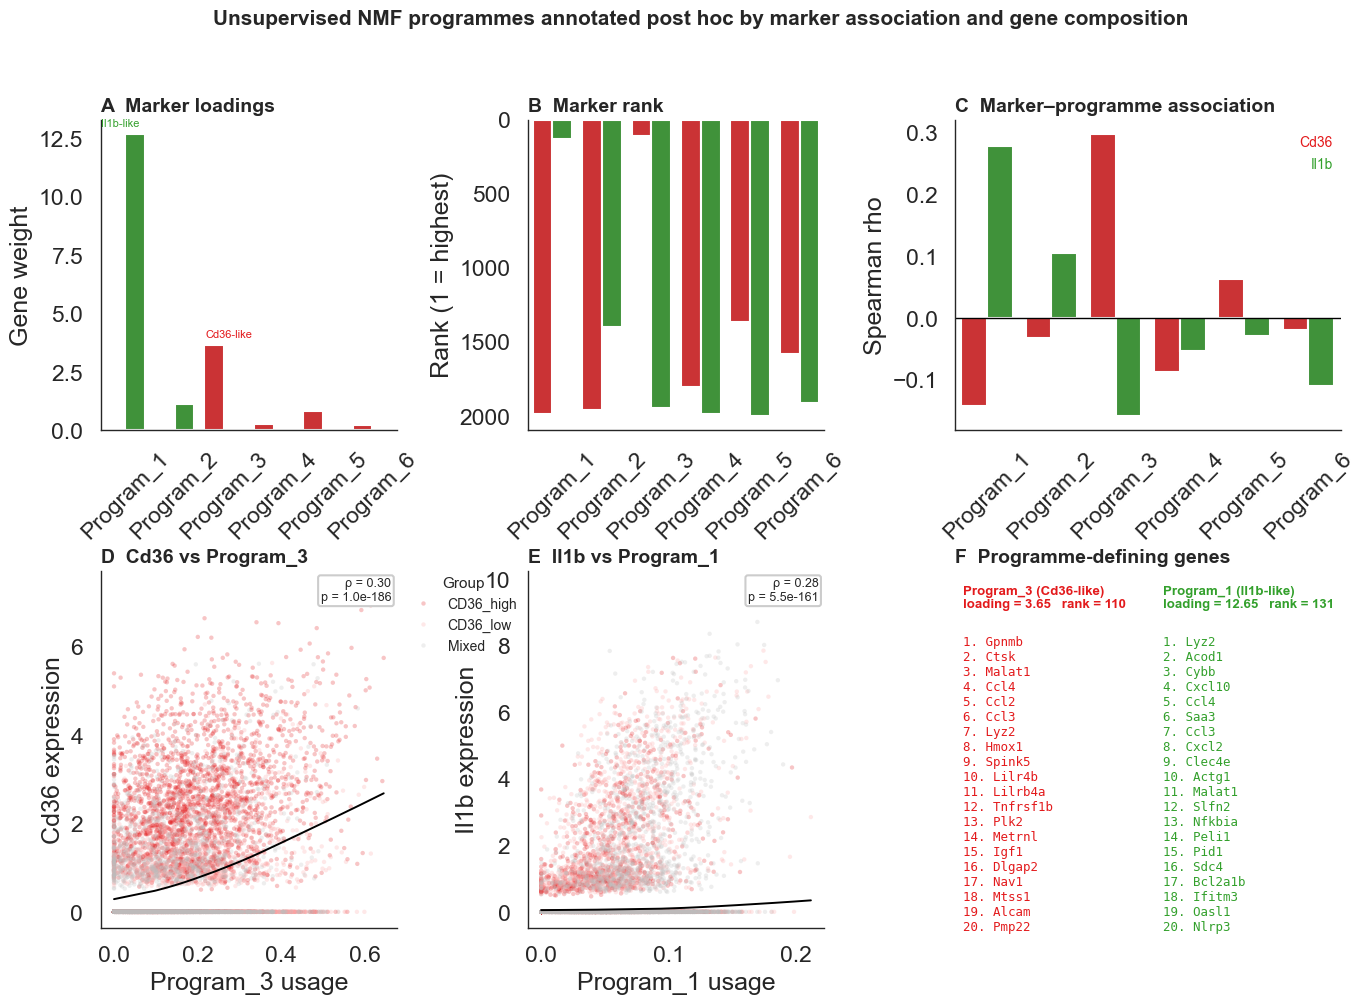

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import matplotlib as mpl

# =========================================================
# SVG / INKSCAPE SETTINGS
# =========================================================
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "DejaVu Sans"

# =========================================================
# COLORS
# =========================================================
group_order = ["CD36_high", "CD36_low", "Mixed"]

group_palette = {
    "CD36_high": "#E31A1C",   # red
    "CD36_low":  "#FCA5A5",   # light red
    "Mixed":     "#BDBDBD"    # grey
}

marker_palette = {
    cd36_gene: "#E31A1C",     # red
    il1b_gene: "#33A02C"      # green
}

# =========================================================
# SETTINGS
# =========================================================
top_n = 20
program_names = list(spectra.index)

sns.set_style("white")
sns.set_context("talk")

# --------------------------------------------------
# BUILD ANNOTATION TABLES
# --------------------------------------------------
marker_loadings = pd.DataFrame({
    "Programme": program_names,
    cd36_gene: spectra[cd36_gene].values if cd36_gene in spectra.columns else np.nan,
    il1b_gene: spectra[il1b_gene].values if il1b_gene in spectra.columns else np.nan,
})

def gene_rank_within_program(program_name, gene_name):
    if gene_name not in spectra.columns:
        return np.nan
    s = spectra.loc[program_name].sort_values(ascending=False)
    ranks = pd.Series(np.arange(1, len(s) + 1), index=s.index)
    return int(ranks[gene_name])

rank_df = pd.DataFrame({
    "Programme": program_names,
    f"{cd36_gene}_rank": [gene_rank_within_program(p, cd36_gene) for p in program_names],
    f"{il1b_gene}_rank": [gene_rank_within_program(p, il1b_gene) for p in program_names],
})

corr_rows = []
for p in program_names:
    rho_cd36, p_cd36 = spearmanr(
        X_log[cd36_gene] if cd36_gene in X_log.columns else np.nan,
        usage[p],
        nan_policy="omit"
    )
    rho_il1b, p_il1b = spearmanr(
        X_log[il1b_gene] if il1b_gene in X_log.columns else np.nan,
        usage[p],
        nan_policy="omit"
    )
    corr_rows.append({
        "Programme": p,
        f"{cd36_gene}_rho": rho_cd36,
        f"{il1b_gene}_rho": rho_il1b,
        f"{cd36_gene}_p": p_cd36,
        f"{il1b_gene}_p": p_il1b,
    })

corr_df = pd.DataFrame(corr_rows)

cd36_top = spectra.loc[cd36_program].sort_values(ascending=False).head(top_n)
il1b_top = spectra.loc[il1b_program].sort_values(ascending=False).head(top_n)

# --------------------------------------------------
# FIGURE
# --------------------------------------------------
fig = plt.figure(figsize=(16, 10.5))
gs = fig.add_gridspec(
    nrows=2, ncols=3,
    width_ratios=[1.0, 1.0, 1.3],
    height_ratios=[1.0, 1.15],
    wspace=0.40, hspace=0.42
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])

# --------------------------------------------------
# PANEL A: marker loadings
# --------------------------------------------------
load_plot = marker_loadings.melt(
    id_vars="Programme",
    var_name="Marker",
    value_name="Loading"
)

sns.barplot(
    data=load_plot,
    x="Programme",
    y="Loading",
    hue="Marker",
    palette=marker_palette,
    ax=ax1
)

ax1.set_title("A  Marker loadings", loc="left", fontweight="bold", fontsize=14)
ax1.set_ylabel("Gene weight")
ax1.set_xlabel("")
ax1.tick_params(axis="x", rotation=45)
ax1.legend_.remove()

# annotate only selected programs, small and offset
for i, p in enumerate(program_names):
    if p == cd36_program:
        y = marker_loadings.loc[marker_loadings["Programme"] == p, cd36_gene].iloc[0]
        ax1.text(i + 0.10, y + 0.25, "Cd36-like", ha="center", va="bottom",
                 fontsize=8, color=marker_palette[cd36_gene])
    if p == il1b_program:
        y = marker_loadings.loc[marker_loadings["Programme"] == p, il1b_gene].iloc[0]
        ax1.text(i - 0.10, y + 0.25, "Il1b-like", ha="center", va="bottom",
                 fontsize=8, color=marker_palette[il1b_gene])

# --------------------------------------------------
# PANEL B: marker rank
# --------------------------------------------------
rank_plot = rank_df.melt(
    id_vars="Programme",
    var_name="Marker",
    value_name="Rank"
)
rank_plot["Marker"] = rank_plot["Marker"].str.replace("_rank", "", regex=False)

sns.barplot(
    data=rank_plot,
    x="Programme",
    y="Rank",
    hue="Marker",
    palette=marker_palette,
    ax=ax2
)

ax2.invert_yaxis()
ax2.set_title("B  Marker rank", loc="left", fontweight="bold", fontsize=14)
ax2.set_ylabel("Rank (1 = highest)")
ax2.set_xlabel("")
ax2.tick_params(axis="x", rotation=45)
ax2.legend_.remove()

# --------------------------------------------------
# PANEL C: marker-program association
# --------------------------------------------------
corr_plot = corr_df.melt(
    id_vars="Programme",
    value_vars=[f"{cd36_gene}_rho", f"{il1b_gene}_rho"],
    var_name="Marker",
    value_name="Spearman_rho"
)
corr_plot["Marker"] = corr_plot["Marker"].str.replace("_rho", "", regex=False)

sns.barplot(
    data=corr_plot,
    x="Programme",
    y="Spearman_rho",
    hue="Marker",
    palette=marker_palette,
    ax=ax3
)

ax3.axhline(0, color="black", lw=1)
ax3.set_title("C  Marker–programme association", loc="left", fontweight="bold", fontsize=14)
ax3.set_ylabel("Spearman rho")
ax3.set_xlabel("")
ax3.tick_params(axis="x", rotation=45)
ax3.legend_.remove()

# add small color key as text instead of legend
ax3.text(0.98, 0.95, "Cd36", color=marker_palette[cd36_gene],
         transform=ax3.transAxes, ha="right", va="top", fontsize=10)
ax3.text(0.98, 0.88, "Il1b", color=marker_palette[il1b_gene],
         transform=ax3.transAxes, ha="right", va="top", fontsize=10)

# --------------------------------------------------
# PANEL D: Cd36 scatter
# --------------------------------------------------
sns.scatterplot(
    data=plot_df,
    x="Cd36_program_usage",
    y=cd36_gene,
    hue="CD36_group",
    hue_order=group_order,
    palette=group_palette,
    alpha=0.25,
    s=10,
    linewidth=0,
    ax=ax4,
    legend=True
)

sns.regplot(
    data=plot_df,
    x="Cd36_program_usage",
    y=cd36_gene,
    scatter=False,
    lowess=True,
    line_kws={"color": "black", "lw": 1.4},
    ax=ax4
)

rho_cd36, p_cd36 = spearmanr(plot_df["Cd36_program_usage"], plot_df[cd36_gene], nan_policy="omit")

ax4.text(
    0.98, 0.98,
    f"ρ = {rho_cd36:.2f}\np = {p_cd36:.1e}",
    transform=ax4.transAxes,
    ha="right", va="top",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.8")
)

ax4.set_title(f"D  {cd36_gene} vs {cd36_program}", loc="left", fontweight="bold", fontsize=14)
ax4.set_xlabel(f"{cd36_program} usage")
ax4.set_ylabel(f"{cd36_gene} expression")

# move only group legend outside the plot
handles, labels = ax4.get_legend_handles_labels()
ax4.legend(
    handles=handles,
    labels=labels,
    title="Group",
    frameon=False,
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    borderaxespad=0,
    fontsize=10,
    title_fontsize=11
)

# --------------------------------------------------
# PANEL E: Il1b scatter
# --------------------------------------------------
sns.scatterplot(
    data=plot_df,
    x="Il1b_program_usage",
    y=il1b_gene,
    hue="CD36_group",
    hue_order=group_order,
    palette=group_palette,
    alpha=0.25,
    s=10,
    linewidth=0,
    ax=ax5,
    legend=False
)

sns.regplot(
    data=plot_df,
    x="Il1b_program_usage",
    y=il1b_gene,
    scatter=False,
    lowess=True,
    line_kws={"color": "black", "lw": 1.4},
    ax=ax5
)

rho_il1b, p_il1b = spearmanr(plot_df["Il1b_program_usage"], plot_df[il1b_gene], nan_policy="omit")

ax5.text(
    0.98, 0.98,
    f"ρ = {rho_il1b:.2f}\np = {p_il1b:.1e}",
    transform=ax5.transAxes,
    ha="right", va="top",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.8")
)

ax5.set_title(f"E  {il1b_gene} vs {il1b_program}", loc="left", fontweight="bold", fontsize=14)
ax5.set_xlabel(f"{il1b_program} usage")
ax5.set_ylabel(f"{il1b_gene} expression")

# --------------------------------------------------
# PANEL F: top genes summary (compact)
# --------------------------------------------------
ax6.axis("off")
ax6.set_title("F  Programme-defining genes", loc="left", fontweight="bold", fontsize=14)

left_header = (
    f"{cd36_program} (Cd36-like)\n"
    f"loading = {marker_loadings.loc[marker_loadings['Programme'] == cd36_program, cd36_gene].iloc[0]:.2f}   "
    f"rank = {rank_df.loc[rank_df['Programme'] == cd36_program, f'{cd36_gene}_rank'].iloc[0]}"
)
right_header = (
    f"{il1b_program} (Il1b-like)\n"
    f"loading = {marker_loadings.loc[marker_loadings['Programme'] == il1b_program, il1b_gene].iloc[0]:.2f}   "
    f"rank = {rank_df.loc[rank_df['Programme'] == il1b_program, f'{il1b_gene}_rank'].iloc[0]}"
)

left_text = "\n".join([f"{i+1}. {g}" for i, g in enumerate(cd36_top.index)])
right_text = "\n".join([f"{i+1}. {g}" for i, g in enumerate(il1b_top.index)])

ax6.text(
    0.02, 0.96, left_header,
    va="top", ha="left",
    fontsize=9.5, color=marker_palette[cd36_gene], fontweight="bold"
)
ax6.text(
    0.02, 0.82, left_text,
    va="top", ha="left",
    fontsize=9, color=marker_palette[cd36_gene], family="monospace"
)

ax6.text(
    0.54, 0.96, right_header,
    va="top", ha="left",
    fontsize=9.5, color=marker_palette[il1b_gene], fontweight="bold"
)
ax6.text(
    0.54, 0.82, right_text,
    va="top", ha="left",
    fontsize=9, color=marker_palette[il1b_gene], family="monospace"
)

# --------------------------------------------------
# FINAL FORMATTING
# --------------------------------------------------
for ax in [ax1, ax2, ax3, ax4, ax5]:
    ax.grid(False)
    ax.spines["left"].set_linewidth(1)
    ax.spines["bottom"].set_linewidth(1)

sns.despine(fig=fig)

fig.suptitle(
    "Unsupervised NMF programmes annotated post hoc by marker association and gene composition",
    fontsize=15,
    fontweight="bold",
    y=0.985
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# --------------------------------------------------
# SAVE
# --------------------------------------------------
fig.savefig("Supp_NMF_validation_layout_clean.svg", bbox_inches="tight")


plt.show()

Validation

CD36-like genes used: ['Cd36', 'Gpnmb', 'Ctsk', 'Hmox1', 'Igf1', 'Trem2', 'Metrnl', 'Plk2']
IL1b-like genes used: ['Il1b', 'Acod1', 'Cxcl2', 'Cybb', 'Nlrp3', 'Tnf', 'Nfkbia', 'Cxcl10']


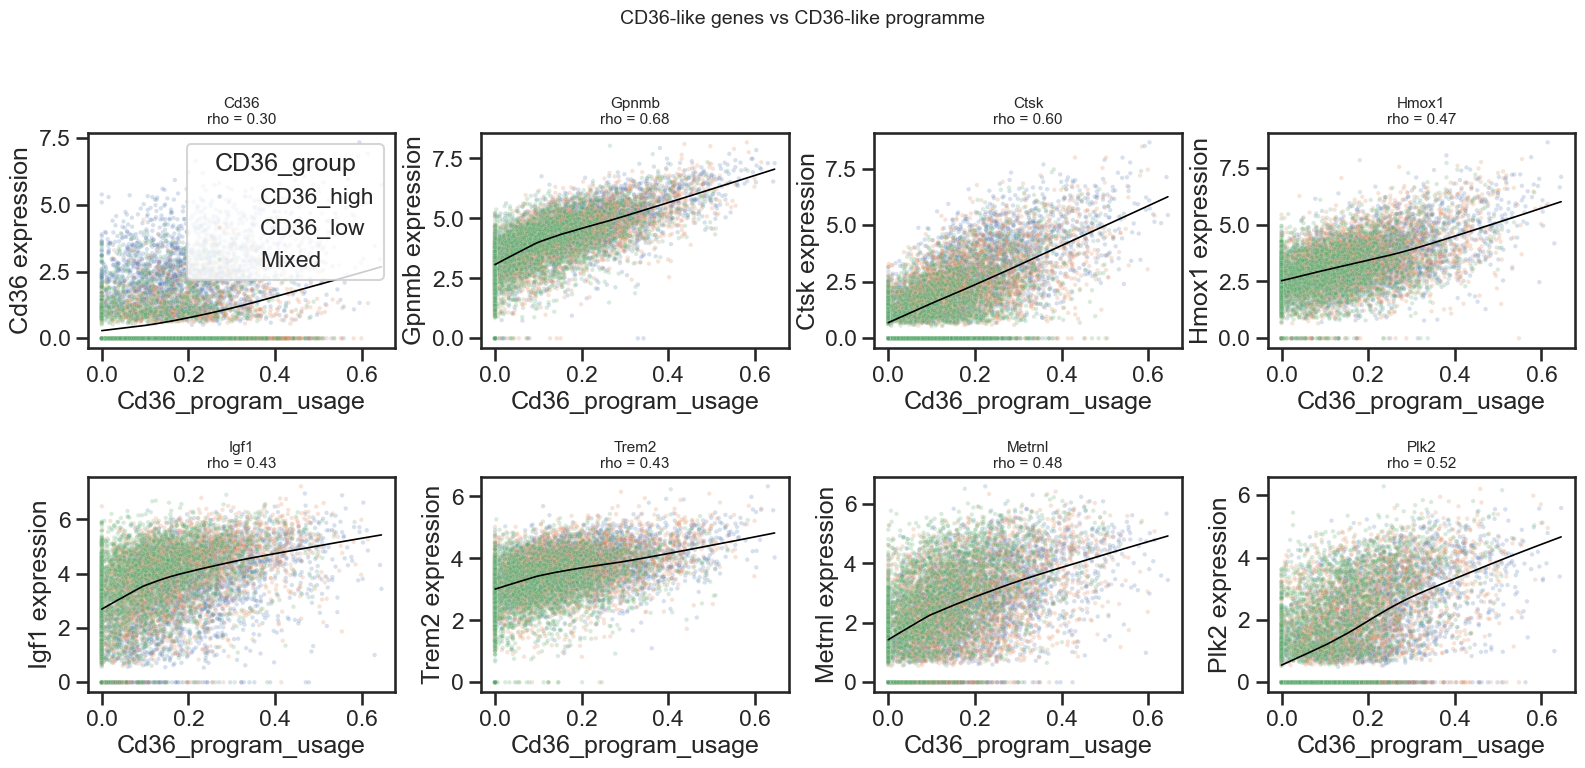

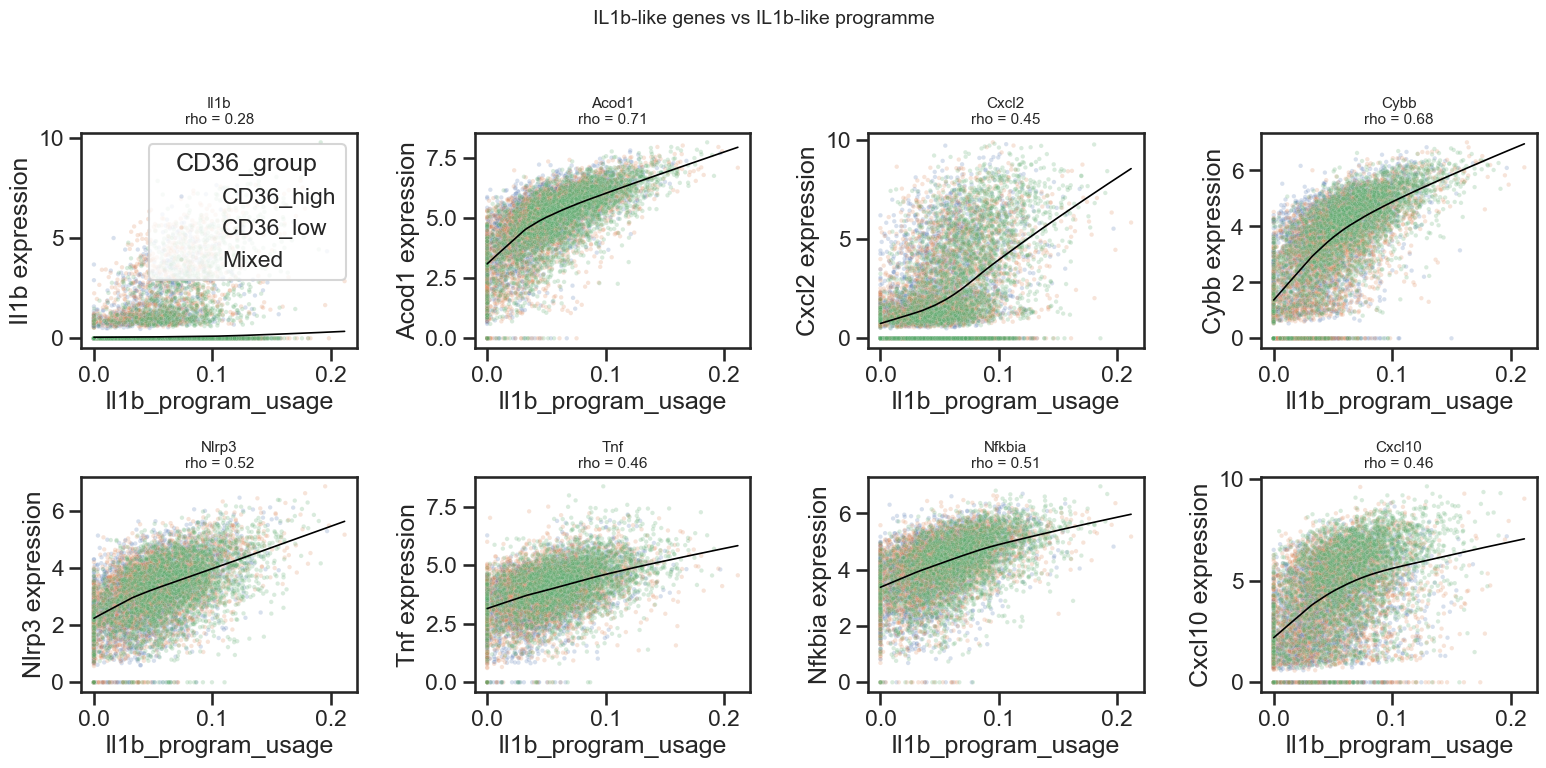

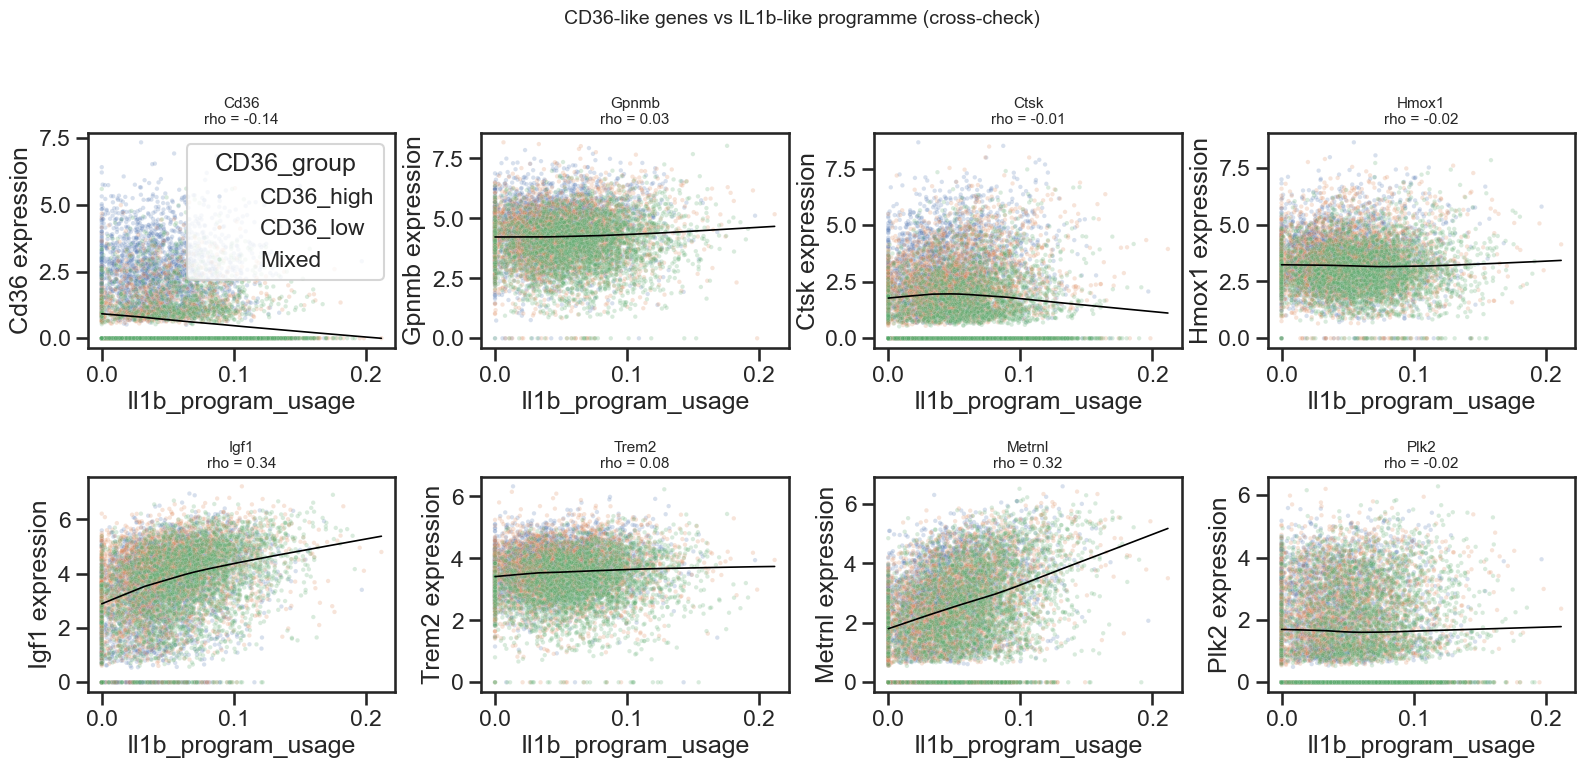

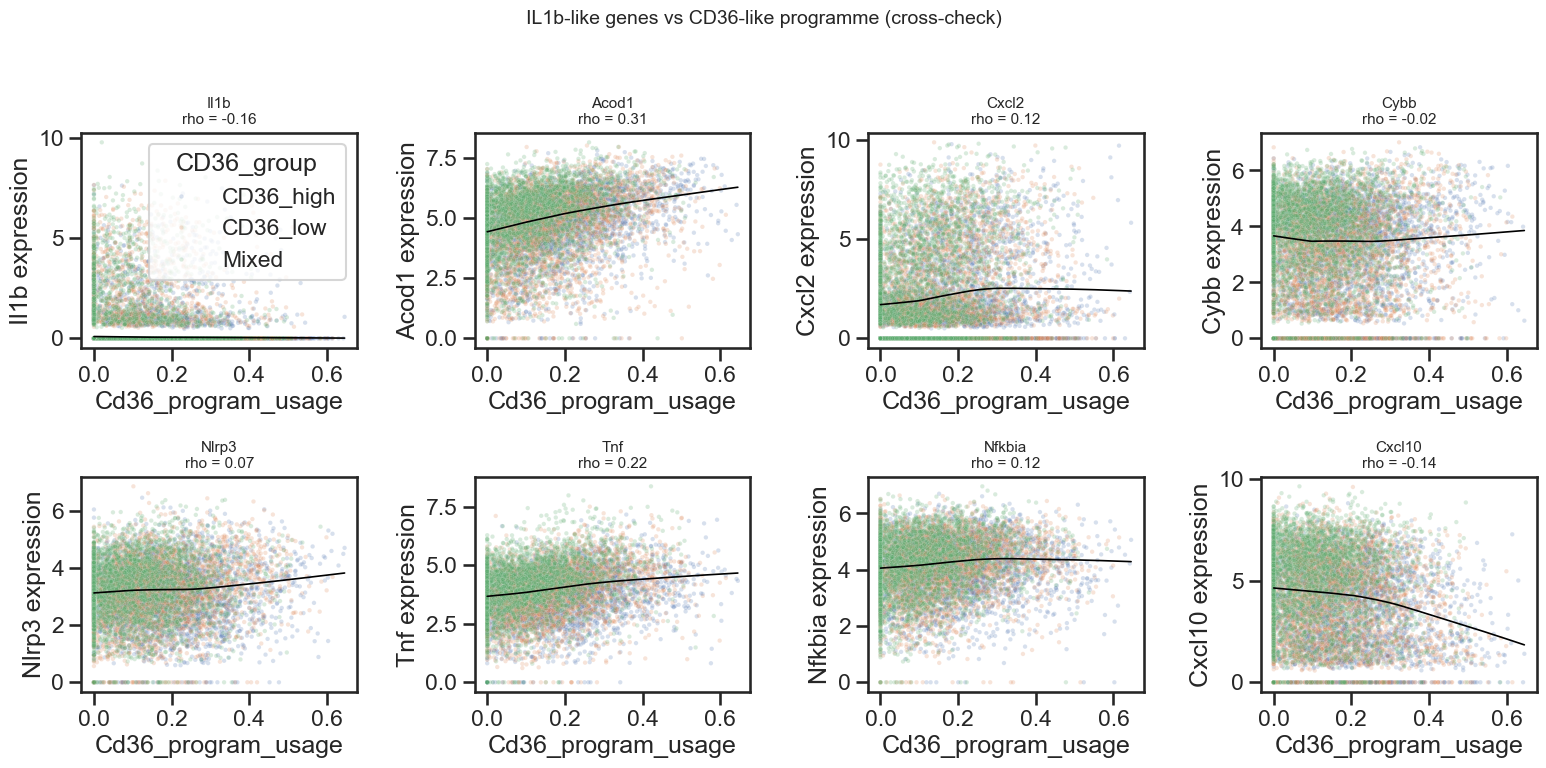

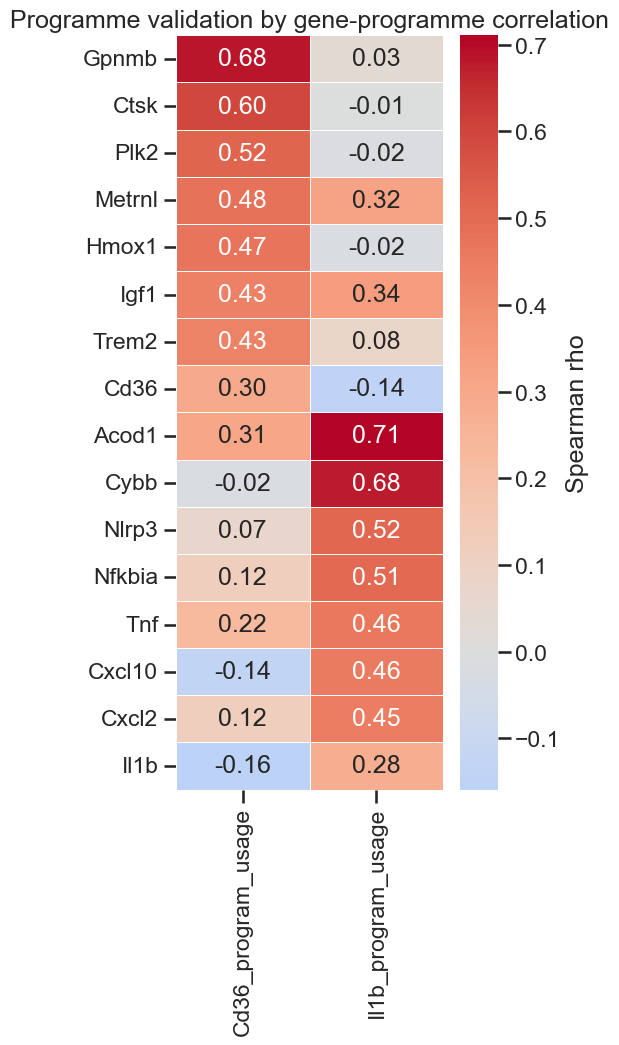

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# --------------------------------------------------
# CURATED GENE SETS
# --------------------------------------------------

#k=5
cd36_check_genes = ["Cd36", "Gpnmb", "Ctsk", "Hmox1", "Igf1", "Trem2", "Plk2", "Pcdh7"]
il1b_check_genes = ["Il1b", "Acod1", "Cxcl2", "Cybb", "Nlrp3", "Tnf", "Nfkbia", "Cxcl10"]
#k=6
cd36_check_genes = ["Cd36", "Gpnmb", "Ctsk", "Hmox1", "Igf1", "Trem2", "Metrnl", "Plk2"]
il1b_check_genes = ["Il1b","Acod1", "Cxcl2", "Cybb", "Nlrp3", "Tnf", "Nfkbia", "Cxcl10"]

# optional second-tier genes
# cd36_check_genes += ["Plk2", "Pcdh7"]
# il1b_check_genes += ["Cybb"]

# --------------------------------------------------
# ADD GENES TO plot_df IF MISSING
# --------------------------------------------------
for g in cd36_check_genes + il1b_check_genes:
    if g in X_log.columns and g not in plot_df.columns:
        plot_df[g] = X_log.loc[plot_df.index, g].values

# keep only genes present
cd36_check_genes = [g for g in cd36_check_genes if g in plot_df.columns]
il1b_check_genes = [g for g in il1b_check_genes if g in plot_df.columns]

print("CD36-like genes used:", cd36_check_genes)
print("IL1b-like genes used:", il1b_check_genes)

# --------------------------------------------------
# HELPER: scatter panel
# --------------------------------------------------
def plot_gene_set_vs_program(genes, program_col, title, ncols=4):
    n = len(genes)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.8*nrows), squeeze=False)
    axes = axes.flatten()

    for i, g in enumerate(genes):
        ax = axes[i]

        sns.scatterplot(
            data=plot_df,
            x=program_col,
            y=g,
            hue="CD36_group",
            alpha=0.22,
            s=10,
            ax=ax,
            legend=(i == 0)
        )

        sns.regplot(
            data=plot_df,
            x=program_col,
            y=g,
            scatter=False,
            lowess=True,
            line_kws={"color": "black", "lw": 1.2},
            ax=ax
        )

        rho, p = spearmanr(plot_df[program_col], plot_df[g], nan_policy="omit")
        ax.set_title(f"{g}\nrho = {rho:.2f}", fontsize=11)
        ax.set_xlabel(program_col)
        ax.set_ylabel(f"{g} expression")

        if i != 0 and ax.get_legend() is not None:
            ax.get_legend().remove()

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# --------------------------------------------------
# PANELS
# --------------------------------------------------
plot_gene_set_vs_program(
    cd36_check_genes,
    "Cd36_program_usage",
    "CD36-like genes vs CD36-like programme"
)

plot_gene_set_vs_program(
    il1b_check_genes,
    "Il1b_program_usage",
    "IL1b-like genes vs IL1b-like programme"
)

plot_gene_set_vs_program(
    cd36_check_genes,
    "Il1b_program_usage",
    "CD36-like genes vs IL1b-like programme (cross-check)"
)

plot_gene_set_vs_program(
    il1b_check_genes,
    "Cd36_program_usage",
    "IL1b-like genes vs CD36-like programme (cross-check)"
)

# --------------------------------------------------
# CORRELATION SUMMARY HEATMAP
# --------------------------------------------------
rows = []
for g in cd36_check_genes + il1b_check_genes:
    rho_cd36, _ = spearmanr(plot_df["Cd36_program_usage"], plot_df[g], nan_policy="omit")
    rho_il1b, _ = spearmanr(plot_df["Il1b_program_usage"], plot_df[g], nan_policy="omit")
    rows.append({
        "gene": g,
        "Cd36_program_usage": rho_cd36,
        "Il1b_program_usage": rho_il1b,
        "group": "CD36_like" if g in cd36_check_genes else "IL1b_like"
    })

corr_df = pd.DataFrame(rows).set_index("gene")

# order genes by their intended programme correlation
ordered_genes = (
    corr_df[corr_df["group"] == "CD36_like"]
    .sort_values("Cd36_program_usage", ascending=False)
    .index.tolist()
    +
    corr_df[corr_df["group"] == "IL1b_like"]
    .sort_values("Il1b_program_usage", ascending=False)
    .index.tolist()
)

heatmap_df = corr_df.loc[ordered_genes, ["Cd36_program_usage", "Il1b_program_usage"]]

plt.figure(figsize=(5.5, 0.55 * len(heatmap_df) + 2))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Spearman rho"}
)
plt.title("Programme validation by gene-programme correlation")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

prog_state
Double_low        7426
Cd36_prog_high     823
Il1b_prog_high     823
Double_high         94
Name: count, dtype: int64

Programme-state fractions per sample:
prog_state  Cd36_prog_high  Double_high  Double_low  Il1b_prog_high
sample                                                             
JM01              0.084936     0.006410    0.876603        0.032051
JM02              0.095665     0.002990    0.871450        0.029895
JM03              0.138107     0.012788    0.759591        0.089514
JM04              0.272476     0.011065    0.683264        0.033195
JM05              0.103115     0.011815    0.827068        0.058002
JM06              0.066959     0.012075    0.843030        0.077936
JM07              0.077660     0.022340    0.798936        0.101064
JM08              0.112200     0.009804    0.837691        0.040305
JM09              0.050188     0.008783    0.831870        0.109159
JM10              0.033439     0.006369    0.835987        0.124204
JM11            

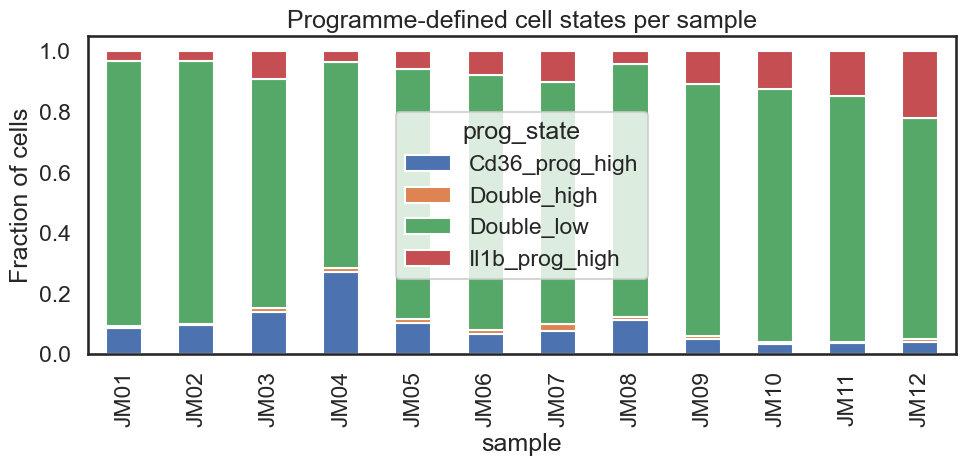

In [5]:
import numpy as np
import pandas as pd

# choose threshold
q = 0.90

plot_df = plot_df.copy()

cd36_thr = plot_df["Cd36_program_usage"].quantile(q)
il1b_thr = plot_df["Il1b_program_usage"].quantile(q)

plot_df["Cd36_prog_high"] = plot_df["Cd36_program_usage"] >= cd36_thr
plot_df["Il1b_prog_high"] = plot_df["Il1b_program_usage"] >= il1b_thr

def assign_prog_state(row):
    if row["Cd36_prog_high"] and row["Il1b_prog_high"]:
        return "Double_high"
    elif row["Cd36_prog_high"]:
        return "Cd36_prog_high"
    elif row["Il1b_prog_high"]:
        return "Il1b_prog_high"
    else:
        return "Double_low"

plot_df["prog_state"] = plot_df.apply(assign_prog_state, axis=1)

print(plot_df["prog_state"].value_counts())

state_summary = (
    plot_df.groupby(["sample", "prog_state"])
    .size()
    .unstack(fill_value=0)
)

state_summary_frac = state_summary.div(state_summary.sum(axis=1), axis=0)

print("\nProgramme-state fractions per sample:")
print(state_summary_frac)

import matplotlib.pyplot as plt

state_summary_frac.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)
plt.ylabel("Fraction of cells")
plt.title("Programme-defined cell states per sample")
plt.tight_layout()
plt.show()

In [9]:
from sklearn.decomposition import NMF
from scipy.stats import spearmanr

def run_nmf_once(X_log, k=6, seed=0, max_iter=1000):
    nmf = NMF(
        n_components=k,
        init="nndsvda",
        random_state=seed,
        max_iter=max_iter
    )
    W = nmf.fit_transform(X_log)
    H = nmf.components_

    usage = pd.DataFrame(
        W,
        index=X_log.index,
        columns=[f"Program_{i+1}" for i in range(k)]
    )
    spectra = pd.DataFrame(
        H,
        index=[f"Program_{i+1}" for i in range(k)],
        columns=X_log.columns
    )
    return usage, spectra

def top_genes_set(spectra, program, top_n=30):
    return set(spectra.loc[program].sort_values(ascending=False).head(top_n).index)

seeds = [0, 1, 2, 3, 4]
k_fixed = 6
top_n = 30

seed_results = []

for seed in seeds:
    usage_i, spectra_i = run_nmf_once(X_log, k=k_fixed, seed=seed, max_iter=1000)
    
    cd36_prog_i = spectra_i["Cd36"].idxmax()
    il1b_prog_i = spectra_i["Il1b"].idxmax()
    
    seed_results.append({
        "seed": seed,
        "usage": usage_i,
        "spectra": spectra_i,
        "cd36_prog": cd36_prog_i,
        "il1b_prog": il1b_prog_i,
        "cd36_top_genes": top_genes_set(spectra_i, cd36_prog_i, top_n=top_n),
        "il1b_top_genes": top_genes_set(spectra_i, il1b_prog_i, top_n=top_n),
    })

# compare each run to seed 0 as reference
ref = seed_results[0]

stability_rows = []
for res in seed_results[1:]:
    cd36_gene_jaccard = len(ref["cd36_top_genes"] & res["cd36_top_genes"]) / len(ref["cd36_top_genes"] | res["cd36_top_genes"])
    il1b_gene_jaccard = len(ref["il1b_top_genes"] & res["il1b_top_genes"]) / len(ref["il1b_top_genes"] | res["il1b_top_genes"])
    
    cd36_usage_ref = ref["usage"][ref["cd36_prog"]]
    cd36_usage_cmp = res["usage"][res["cd36_prog"]]
    il1b_usage_ref = ref["usage"][ref["il1b_prog"]]
    il1b_usage_cmp = res["usage"][res["il1b_prog"]]
    
    cd36_usage_rho, _ = spearmanr(cd36_usage_ref, cd36_usage_cmp)
    il1b_usage_rho, _ = spearmanr(il1b_usage_ref, il1b_usage_cmp)
    
    stability_rows.append({
        "seed": res["seed"],
        "Cd36_topgene_jaccard": cd36_gene_jaccard,
        "Il1b_topgene_jaccard": il1b_gene_jaccard,
        "Cd36_usage_rho": cd36_usage_rho,
        "Il1b_usage_rho": il1b_usage_rho
    })

stability_df = pd.DataFrame(stability_rows)
print("\n=== Stability across seeds (vs seed 0) ===")
print(stability_df)


=== Stability across seeds (vs seed 0) ===
   seed  Cd36_topgene_jaccard  Il1b_topgene_jaccard  Cd36_usage_rho  \
0     1                   1.0                   1.0             1.0   
1     2                   1.0                   1.0             1.0   
2     3                   1.0                   1.0             1.0   
3     4                   1.0                   1.0             1.0   

   Il1b_usage_rho  
0             1.0  
1             1.0  
2             1.0  
3             1.0  


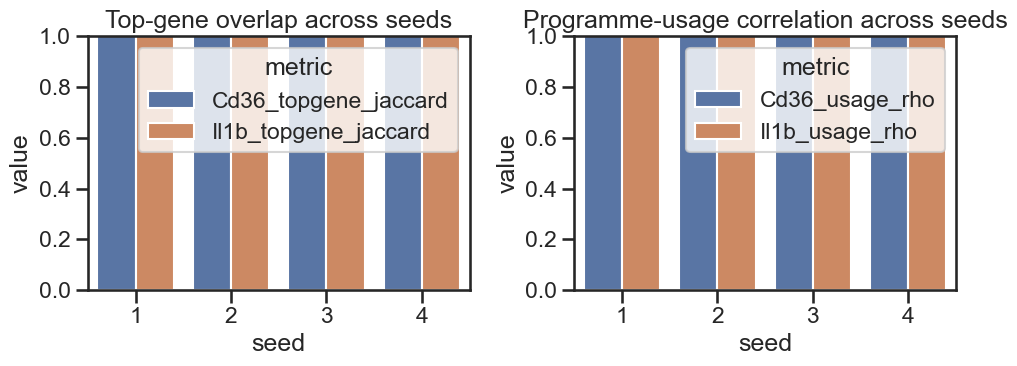

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(data=stability_df.melt(
    id_vars="seed",
    value_vars=["Cd36_topgene_jaccard", "Il1b_topgene_jaccard"],
    var_name="metric",
    value_name="value"
), x="seed", y="value", hue="metric", ax=axes[0])
axes[0].set_title("Top-gene overlap across seeds")
axes[0].set_ylim(0, 1)

sns.barplot(data=stability_df.melt(
    id_vars="seed",
    value_vars=["Cd36_usage_rho", "Il1b_usage_rho"],
    var_name="metric",
    value_name="value"
), x="seed", y="value", hue="metric", ax=axes[1])
axes[1].set_title("Programme-usage correlation across seeds")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [10]:
k_list = [4, 5, 6, 7, 8]
k_results = []

for k in k_list:
    usage_k, spectra_k = run_nmf_once(X_log, k=k, seed=0, max_iter=1000)
    
    cd36_prog_k = spectra_k["Cd36"].idxmax()
    il1b_prog_k = spectra_k["Il1b"].idxmax()
    
    cd36_top = spectra_k.loc[cd36_prog_k].sort_values(ascending=False).head(20).index.tolist()
    il1b_top = spectra_k.loc[il1b_prog_k].sort_values(ascending=False).head(20).index.tolist()
    
    k_results.append({
        "k": k,
        "cd36_prog": cd36_prog_k,
        "il1b_prog": il1b_prog_k,
        "cd36_top20": cd36_top,
        "il1b_top20": il1b_top,
        "usage": usage_k,
        "spectra": spectra_k
    })

for res in k_results:
    print(f"\n=== k = {res['k']} ===")
    print(f"Cd36-like programme: {res['cd36_prog']}")
    print("Top Cd36-like genes:", ", ".join(res["cd36_top20"][:10]))
    print(f"Il1b-like programme: {res['il1b_prog']}")
    print("Top Il1b-like genes:", ", ".join(res["il1b_top20"][:10]))


=== k = 4 ===
Cd36-like programme: Program_1
Top Cd36-like genes: Ccl4, Lyz2, Ccl3, Acod1, Clec4e, Cxcl10, Cybb, Malat1, Actg1, Lilrb4a
Il1b-like programme: Program_1
Top Il1b-like genes: Ccl4, Lyz2, Ccl3, Acod1, Clec4e, Cxcl10, Cybb, Malat1, Actg1, Lilrb4a

=== k = 5 ===
Cd36-like programme: Program_3
Top Cd36-like genes: Gpnmb, Ccl3, Ccl4, Lyz2, Ctsk, Spink5, Malat1, Ccl2, Hmox1, Vim
Il1b-like programme: Program_1
Top Il1b-like genes: Lyz2, Acod1, Ccl4, Cxcl10, Cybb, Ccl3, Saa3, Cxcl2, Clec4e, Slfn2

=== k = 6 ===
Cd36-like programme: Program_3
Top Cd36-like genes: Gpnmb, Ctsk, Malat1, Ccl4, Ccl2, Ccl3, Lyz2, Hmox1, Spink5, Lilr4b
Il1b-like programme: Program_1
Top Il1b-like genes: Lyz2, Acod1, Cybb, Cxcl10, Ccl4, Saa3, Ccl3, Cxcl2, Clec4e, Actg1

=== k = 7 ===
Cd36-like programme: Program_3
Top Cd36-like genes: Gpnmb, Ctsk, Malat1, Ccl2, Hmox1, Lyz2, Ccl4, Ccl3, Spink5, Lilrb4a
Il1b-like programme: Program_1
Top Il1b-like genes: Cxcl10, Ccl4, Cybb, Acod1, Cxcl2, Saa3, Lyz2, Ccl3, P

In [11]:
ref_k = [r for r in k_results if r["k"] == 6][0]

rows = []
for res in k_results:
    cd36_j = len(set(ref_k["cd36_top20"]) & set(res["cd36_top20"])) / len(set(ref_k["cd36_top20"]) | set(res["cd36_top20"]))
    il1b_j = len(set(ref_k["il1b_top20"]) & set(res["il1b_top20"])) / len(set(ref_k["il1b_top20"]) | set(res["il1b_top20"]))
    
    cd36_rho, _ = spearmanr(
        ref_k["usage"][ref_k["cd36_prog"]],
        res["usage"][res["cd36_prog"]]
    )
    il1b_rho, _ = spearmanr(
        ref_k["usage"][ref_k["il1b_prog"]],
        res["usage"][res["il1b_prog"]]
    )
    
    rows.append({
        "k": res["k"],
        "Cd36_top20_jaccard": cd36_j,
        "Il1b_top20_jaccard": il1b_j,
        "Cd36_usage_rho": cd36_rho,
        "Il1b_usage_rho": il1b_rho
    })

k_stability_df = pd.DataFrame(rows)
print("\n=== Stability across k (vs k=6) ===")
print(k_stability_df)


=== Stability across k (vs k=6) ===
   k  Cd36_top20_jaccard  Il1b_top20_jaccard  Cd36_usage_rho  Il1b_usage_rho
0  4            0.250000            0.481481        0.540415        0.730133
1  5            0.481481            0.904762        0.941798        0.987383
2  6            1.000000            1.000000        1.000000        1.000000
3  7            1.000000            0.666667        0.996504        0.930960
4  8            0.250000            0.666667        0.828574        0.925208


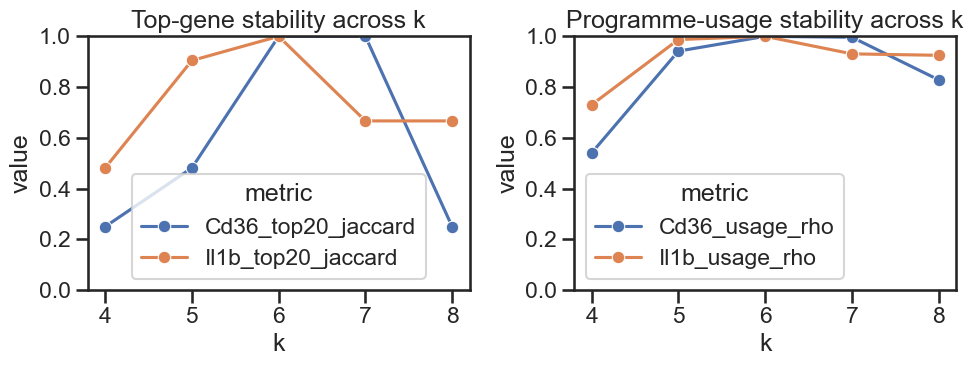

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.lineplot(
    data=k_stability_df.melt(
        id_vars="k",
        value_vars=["Cd36_top20_jaccard", "Il1b_top20_jaccard"],
        var_name="metric",
        value_name="value"
    ),
    x="k", y="value", hue="metric", marker="o", ax=axes[0]
)
axes[0].set_title("Top-gene stability across k")
axes[0].set_ylim(0, 1)

sns.lineplot(
    data=k_stability_df.melt(
        id_vars="k",
        value_vars=["Cd36_usage_rho", "Il1b_usage_rho"],
        var_name="metric",
        value_name="value"
    ),
    x="k", y="value", hue="metric", marker="o", ax=axes[1]
)
axes[1].set_title("Programme-usage stability across k")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

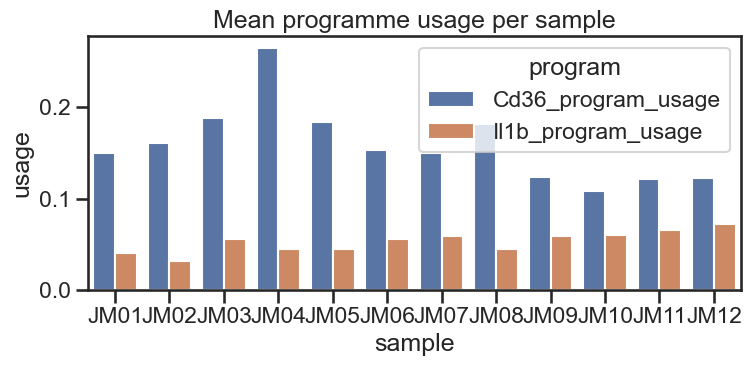

In [13]:
sample_prog = (
    plot_df.groupby("sample", as_index=False)[["Cd36_program_usage", "Il1b_program_usage"]]
    .mean()
)

sample_prog["CD36_group"] = sample_prog["sample"].map(
    {s: "CD36_high" for s in ["JM01", "JM03", "JM04", "JM05"]} |
    {s: "CD36_low" for s in ["JM02", "JM06", "JM07", "JM08"]} |
    {s: "Mixed" for s in ["JM09", "JM10", "JM11", "JM12"]}
)

plt.figure(figsize=(8, 4))
sample_prog_m = sample_prog.melt(
    id_vars=["sample", "CD36_group"],
    value_vars=["Cd36_program_usage", "Il1b_program_usage"],
    var_name="program",
    value_name="usage"
)

sns.barplot(
    data=sample_prog_m,
    x="sample",
    y="usage",
    hue="program"
)
plt.title("Mean programme usage per sample")
plt.tight_layout()
plt.show()

## Annotate other gene programs based on spectra

In [14]:
for prog in spectra.index:
    print(f"\n=== {prog} ===")
    print(spectra.loc[prog].sort_values(ascending=False).head(20))


=== Program_1 ===
Symbol
Lyz2       38.106545
Acod1      36.807606
Cybb       35.941209
Cxcl10     35.829036
Ccl4       34.569181
Saa3       32.356479
Ccl3       31.075710
Cxcl2      29.846986
Clec4e     26.471552
Actg1      25.778132
Malat1     25.627122
Slfn2      25.517093
Nfkbia     25.061043
Peli1      24.863184
Pid1       24.862579
Sdc4       24.730176
Bcl2a1b    24.440123
Ifitm3     24.436153
Oasl1      24.024462
Nlrp3      23.739676
Name: Program_1, dtype: float64

=== Program_2 ===
Symbol
Hist1h1b     19.169789
Top2a        18.744959
Hist1h1e     15.300313
Hist1h2ae    14.549872
Hist1h2ap    14.302298
Mki67        12.729498
Hist1h4d     12.353582
Cdk1         12.073837
Prc1         11.505699
Hmgb2        11.483519
Hist2h2ac    11.401360
Smc4         10.979461
Incenp       10.458148
Pclaf        10.296117
Smc2         10.052249
Ccl2          9.676363
Mis18bp1      9.588322
Ube2c         9.158491
Fbxo5         9.058978
Cenpf         9.037616
Name: Program_2, dtype: float64

===

Unsupervised NMF decomposition identified six transcriptional programmes corresponding to inflammatory activation, tissue-remodelling, cell cycle progression (S-phase and G2/M), early replication, and motility/adhesion states. Programme identities were assigned using an overlap-based scoring approach with curated marker gene sets.


=== Automatic programme annotations ===
Program_1          Inflammatory_Il1b
Program_2         S_phase_cell_cycle
Program_3      Cd36_like_remodelling
Program_4             G2M_cell_cycle
Program_5          Motility_adhesion
Program_6    Early_cycle_replication
Name: Annotation, dtype: object

=== Annotation summary table ===
                       Final_label               Best_match  Best_n_overlap  \
Programme                                                                     
Program_1        Inflammatory_Il1b        Inflammatory_Il1b              15   
Program_2       S_phase_cell_cycle       S_phase_cell_cycle              18   
Program_3    Cd36_like_remodelling    Cd36_like_remodelling              13   
Program_4           G2M_cell_cycle           G2M_cell_cycle              15   
Program_5        Motility_adhesion        Motility_adhesion              13   
Program_6  Early_cycle_replication  Early_cycle_replication               9   

                                      

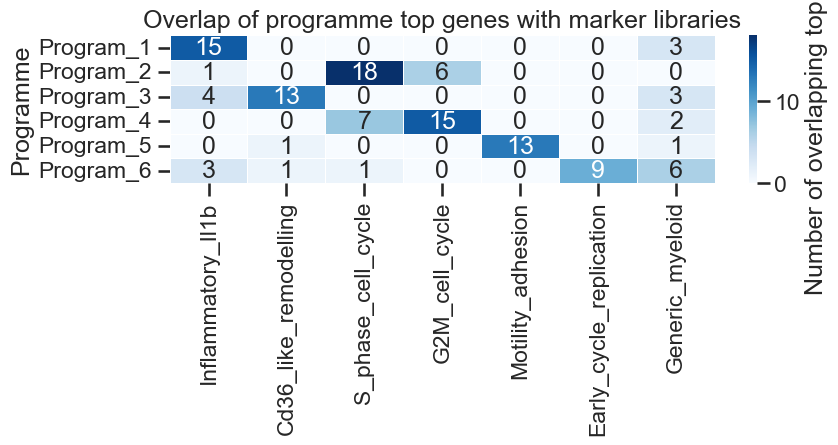

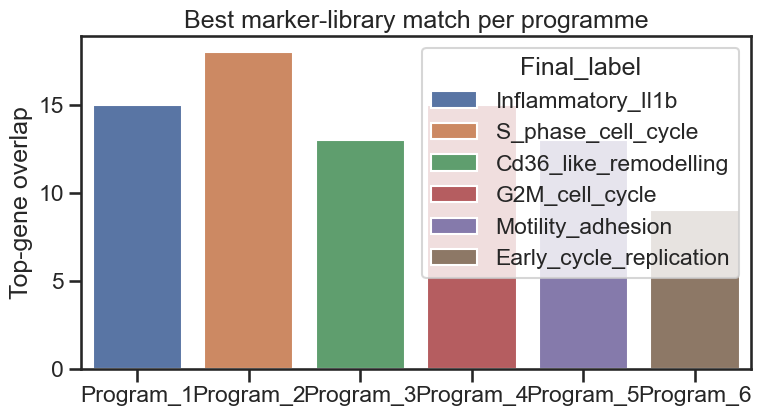


=== Top 10 genes per programme ===
  Program_1  Program_2 Program_3 Program_4 Program_5 Program_6
0      Lyz2   Hist1h1b     Gpnmb     Ube2c  Mir99ahg      Lyz2
1     Acod1      Top2a      Ctsk     Cenpf      Pid1      Ccl3
2      Cybb   Hist1h1e    Malat1      Hmmr    Malat1      Nasp
3    Cxcl10  Hist1h2ae      Ccl4     Cdc20     Cdk14       Dut
4      Ccl4  Hist1h2ap      Ccl2     Cenpa     Itga4     Stmn1
5      Saa3      Mki67      Ccl3     Mki67  Kcnq1ot1       Vim
6      Ccl3   Hist1h4d      Lyz2      Cks2    Calcrl    S100a6
7     Cxcl2       Cdk1     Hmox1      Tpx2     Trps1     Ccnd1
8    Clec4e       Prc1    Spink5     Cenpe     Lrmda    Tubb4b
9     Actg1      Hmgb2    Lilr4b    Tubb4b  Ralgapa2       Dek


In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# SINGLE-CODE DATA-DRIVEN PROGRAMME ANNOTATION
# Requires:
#   spectra  -> DataFrame: rows = programmes, columns = genes
# =========================================================

# -----------------------------
# 1. marker libraries
# -----------------------------
marker_library = {
    "Inflammatory_Il1b": {
        "Il1b","Acod1","Cxcl2","Cxcl10","Ccl3","Ccl4","Nlrp3","Tnf",
        "Nfkbia","Cybb","Clec4e","Ifitm3","Oasl1","Bcl2a1b","Saa3","Peli1"
    },
    "Cd36_like_remodelling": {
        "Cd36","Gpnmb","Ctsk","Hmox1","Igf1","Trem2","Metrnl","Plin2",
        "Tnfrsf1b","Plk2","Pcdh7","Alcam","Lilrb4a","Lilr4b","Dlgap2",
        "Mtss1","Lpl"
    },
    "S_phase_cell_cycle": {
        "Top2a","Hist1h1b","Hist1h1e","Hist1h2ae","Hist1h2ap","Hist1h4d",
        "Hist2h2ac","Mki67","Cdk1","Prc1","Hmgb2","Smc2","Smc4",
        "Incenp","Pclaf","Fbxo5","Mis18bp1","Cenpf"
    },
    "G2M_cell_cycle": {
        "Ube2c","Cenpf","Hmmr","Cdc20","Cenpa","Mki67","Cks2","Tpx2",
        "Cenpe","Birc5","Ccnb1","Cdca8","Plk1","Kif20b","Cks1b"
    },
    "Motility_adhesion": {
        "Itga4","Dock2","Diaph2","Peak1","Ahnak","Calcrl","Pla2g4a",
        "Ralgapa2","Srgap2","Gphn","Trps1","Lrmda","Cdk14"
    },
    "Early_cycle_replication": {
        "Nasp","Dut","Stmn1","Ccnd1","Pcna","Gmnn","Mcm7","Tipin","Dek"
    },
    "Generic_myeloid": {
        "Lyz2","Vim","Actg1","S100a6","Comt","Cited2","Malat1"
    }
}

# -----------------------------
# 2. helper functions
# -----------------------------
def get_top_genes(spectra, prog, top_n=30):
    return list(spectra.loc[prog].sort_values(ascending=False).head(top_n).index)

def score_program_top_genes(top_genes, marker_library):
    top_set = set(top_genes)
    rows = []

    for label, markers in marker_library.items():
        overlap = top_set & markers
        rows.append({
            "Label": label,
            "n_overlap": len(overlap),
            "frac_of_top": len(overlap) / len(top_set),
            "frac_of_marker_set": len(overlap) / len(markers),
            "overlap_genes": ", ".join(sorted(overlap))
        })

    return pd.DataFrame(rows).sort_values(
        ["n_overlap", "frac_of_top", "frac_of_marker_set"],
        ascending=False
    ).reset_index(drop=True)

def choose_final_label(score_df, min_overlap=3):
    best = score_df.iloc[0]
    second = score_df.iloc[1]

    if best["n_overlap"] < min_overlap:
        return "Other"

    if (
        best["Label"] in {"S_phase_cell_cycle", "G2M_cell_cycle"}
        and second["Label"] in {"S_phase_cell_cycle", "G2M_cell_cycle"}
    ):
        return best["Label"]

    if best["Label"] == "Generic_myeloid" and second["n_overlap"] >= min_overlap:
        return second["Label"]

    return best["Label"]

# -----------------------------
# 3. run annotation
# -----------------------------
top_n = 30
min_overlap = 3

annotation_rows = []
final_labels = {}
score_tables = {}
overlap_heat_rows = []

for prog in spectra.index:
    top_genes = get_top_genes(spectra, prog, top_n=top_n)
    score_df = score_program_top_genes(top_genes, marker_library)
    final_label = choose_final_label(score_df, min_overlap=min_overlap)

    final_labels[prog] = final_label
    score_tables[prog] = score_df.copy()

    best = score_df.iloc[0]
    second = score_df.iloc[1]

    annotation_rows.append({
        "Programme": prog,
        "Final_label": final_label,
        "Best_match": best["Label"],
        "Best_n_overlap": best["n_overlap"],
        "Best_overlap_genes": best["overlap_genes"],
        "Second_match": second["Label"],
        "Second_n_overlap": second["n_overlap"],
        "Top_genes": ", ".join(top_genes[:12])
    })

    heat_row = {"Programme": prog}
    top_set = set(top_genes)
    for label, markers in marker_library.items():
        heat_row[label] = len(top_set & markers)
    overlap_heat_rows.append(heat_row)

program_annotations_auto = pd.Series(final_labels, name="Annotation")
annotation_table_auto = pd.DataFrame(annotation_rows).set_index("Programme")
overlap_heat_df = pd.DataFrame(overlap_heat_rows).set_index("Programme")

# -----------------------------
# 4. print outputs
# -----------------------------
print("\n=== Automatic programme annotations ===")
print(program_annotations_auto)

print("\n=== Annotation summary table ===")
print(annotation_table_auto)

for prog in spectra.index:
    print(f"\n=== {prog} ===")
    print("Top genes:")
    print(spectra.loc[prog].sort_values(ascending=False).head(20))
    print("\nScoring against marker libraries:")
    print(score_tables[prog][["Label", "n_overlap", "overlap_genes"]])

# -----------------------------
# 5. plots
# -----------------------------
# Heatmap of overlaps
plt.figure(figsize=(9, 4.8))
sns.heatmap(
    overlap_heat_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Number of overlapping top genes"}
)
plt.title("Overlap of programme top genes with marker libraries")
plt.tight_layout()
plt.show()

# Barplot of best overlap per programme
best_overlap_plot = annotation_table_auto.reset_index()[["Programme", "Final_label", "Best_n_overlap"]]

plt.figure(figsize=(8, 4.5))
sns.barplot(
    data=best_overlap_plot,
    x="Programme",
    y="Best_n_overlap",
    hue="Final_label"
)
plt.title("Best marker-library match per programme")
plt.ylabel("Top-gene overlap")
plt.xlabel("")
plt.tight_layout()
plt.show()

# Top 10 genes as a compact table
top10_df = pd.DataFrame({
    prog: pd.Series(get_top_genes(spectra, prog, top_n=10))
    for prog in spectra.index
})
print("\n=== Top 10 genes per programme ===")
print(top10_df)

C:\Users\truon\AppData\Local\Temp\ipykernel_10932\4066573407.py:272: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.985])


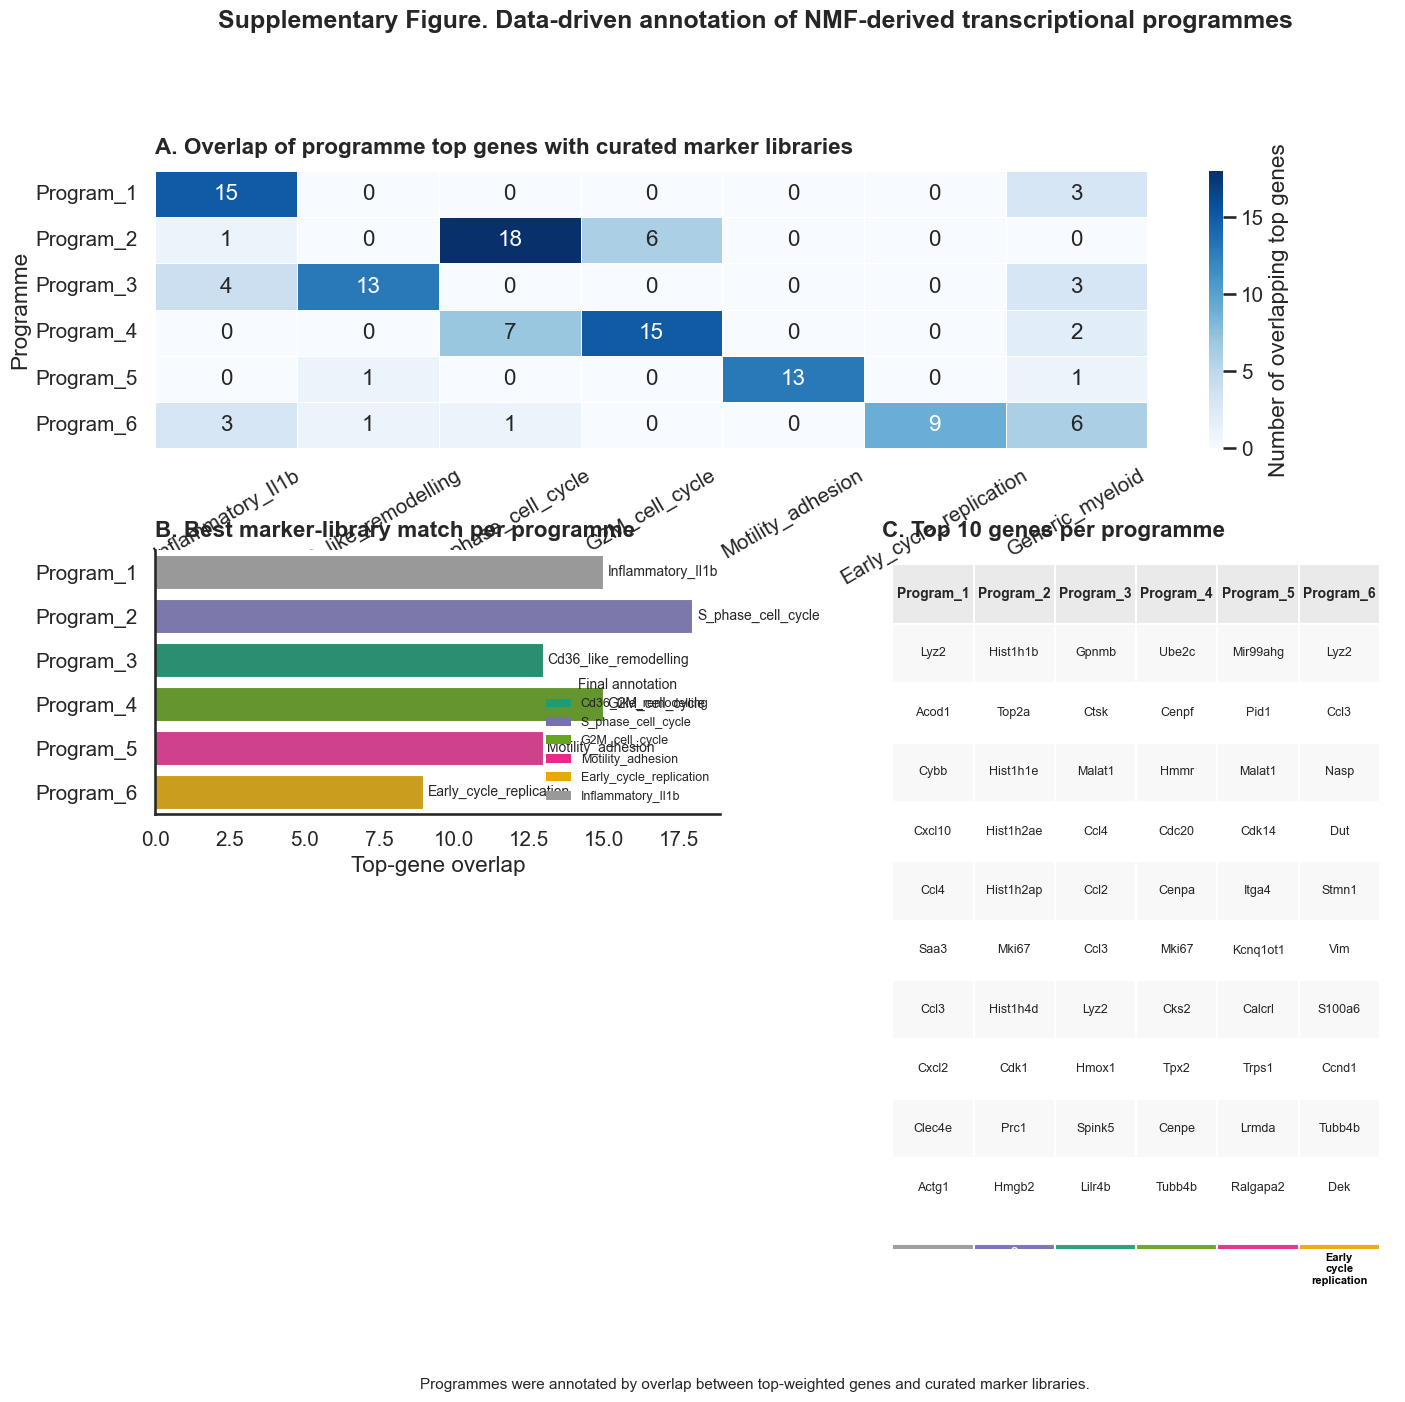

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# PUBLICATION-READY FIGURE FOR PROGRAMME ANNOTATION
# Requires objects already created:
#   spectra
#   annotation_table_auto
#   overlap_heat_df
#   program_annotations_auto
#   marker_library
#   get_top_genes()
# =========================================================

# ---------------------------------------------------------
# SETTINGS
# ---------------------------------------------------------
top_n_display = 10

sns.set_style("white")
sns.set_context("talk", font_scale=0.9)

# consistent programme order
prog_order = list(spectra.index)

# ordered marker libraries for plotting
marker_order = [
    "Inflammatory_Il1b",
    "Cd36_like_remodelling",
    "S_phase_cell_cycle",
    "G2M_cell_cycle",
    "Motility_adhesion",
    "Early_cycle_replication",
    "Generic_myeloid"
]

# reorder tables
overlap_plot = overlap_heat_df.loc[prog_order, marker_order].copy()
annot_plot = annotation_table_auto.loc[prog_order].copy()

# build top-gene matrix
top_gene_matrix = pd.DataFrame({
    prog: pd.Series(get_top_genes(spectra, prog, top_n=top_n_display))
    for prog in prog_order
})

# ---------------------------------------------------------
# COLOUR MAPS
# ---------------------------------------------------------
label_palette = {
    "Inflammatory_NFkB": "#d95f02",
    "Cd36_like_remodelling": "#1b9e77",
    "S_phase_cell_cycle": "#7570b3",
    "G2M_cell_cycle": "#66a61e",
    "Motility_adhesion": "#e7298a",
    "Early_cycle_replication": "#e6ab02",
    "Generic_myeloid": "#a6761d",
    "Other": "#bdbdbd"
}

# if unexpected labels appear
for lbl in annot_plot["Final_label"].unique():
    if lbl not in label_palette:
        label_palette[lbl] = "#999999"

bar_colors = annot_plot["Final_label"].map(label_palette)

# ---------------------------------------------------------
# FIGURE LAYOUT
# ---------------------------------------------------------
fig = plt.figure(figsize=(16, 14))
gs = fig.add_gridspec(
    nrows=3, ncols=2,
    height_ratios=[1.0, 0.95, 1.2],
    width_ratios=[1.1, 1.0],
    hspace=0.35,
    wspace=0.30
)

axA = fig.add_subplot(gs[0, :])   # heatmap full width
axB = fig.add_subplot(gs[1, 0])   # barplot
axC = fig.add_subplot(gs[1:, 1])  # top genes table-like panel

# =========================================================
# PANEL A — OVERLAP HEATMAP
# =========================================================
sns.heatmap(
    overlap_plot,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Number of overlapping top genes"},
    ax=axA
)

axA.set_title(
    "A. Overlap of programme top genes with curated marker libraries",
    loc="left",
    fontweight="bold",
    pad=12
)
axA.set_xlabel("")
axA.set_ylabel("Programme")
axA.tick_params(axis="x", rotation=30)
axA.tick_params(axis="y", rotation=0)

# =========================================================
# PANEL B — BEST MATCH BARPLOT
# =========================================================
bar_df = annot_plot.reset_index()[["Programme", "Final_label", "Best_n_overlap", "Best_match"]].copy()
bar_df["Programme"] = pd.Categorical(bar_df["Programme"], categories=prog_order, ordered=True)
bar_df = bar_df.sort_values("Programme")

sns.barplot(
    data=bar_df,
    y="Programme",
    x="Best_n_overlap",
    hue="Final_label",
    dodge=False,
    palette=label_palette,
    ax=axB
)

# remove auto legend
if axB.legend_ is not None:
    axB.legend_.remove()

# annotate best match label at bar ends
for i, row in enumerate(bar_df.itertuples(index=False)):
    axB.text(
        row.Best_n_overlap + 0.12,
        i,
        row.Best_match,
        va="center",
        fontsize=10
    )

axB.set_title(
    "B. Best marker-library match per programme",
    loc="left",
    fontweight="bold",
    pad=10
)
axB.set_xlabel("Top-gene overlap")
axB.set_ylabel("")
sns.despine(ax=axB)

# custom legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=color, edgecolor="none", label=label)
    for label, color in label_palette.items()
    if label in bar_df["Final_label"].unique()
]
axB.legend(
    handles=legend_handles,
    title="Final annotation",
    frameon=False,
    loc="lower right",
    fontsize=9,
    title_fontsize=10
)

# =========================================================
# PANEL C — TOP GENES TABLE-LIKE DISPLAY
# =========================================================
axC.axis("off")
axC.set_title(
    "C. Top 10 genes per programme",
    loc="left",
    fontweight="bold",
    pad=10
)

# draw a clean table manually for better control
n_rows = top_gene_matrix.shape[0]
n_cols = top_gene_matrix.shape[1]

# layout parameters in axis coordinates
x0, y0 = 0.02, 0.98
col_w = 0.95 / n_cols
row_h = 0.085

# header
for j, prog in enumerate(top_gene_matrix.columns):
    x = x0 + j * col_w
    axC.add_patch(plt.Rectangle(
        (x, y0 - row_h), col_w, row_h,
        facecolor="#eaeaea", edgecolor="white"
    ))
    axC.text(
        x + col_w / 2,
        y0 - row_h / 2,
        prog,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# rows
for i in range(n_rows):
    y = y0 - (i + 2) * row_h
    for j, prog in enumerate(top_gene_matrix.columns):
        x = x0 + j * col_w
        gene = top_gene_matrix.iloc[i, j]

        # alternate row shading
        facecolor = "#f8f8f8" if i % 2 == 0 else "white"

        axC.add_patch(plt.Rectangle(
            (x, y), col_w, row_h,
            facecolor=facecolor, edgecolor="white"
        ))

        axC.text(
            x + col_w / 2,
            y + row_h / 2,
            gene,
            ha="center",
            va="center",
            fontsize=9
        )

# add final annotation row underneath headers
for j, prog in enumerate(top_gene_matrix.columns):
    x = x0 + j * col_w
    label = annot_plot.loc[prog, "Final_label"]
    color = label_palette.get(label, "#999999")

    y_ann = y0 - (n_rows + 2.3) * row_h
    axC.add_patch(plt.Rectangle(
        (x, y_ann), col_w, row_h * 0.85,
        facecolor=color, edgecolor="white", alpha=0.95
    ))
    axC.text(
        x + col_w / 2,
        y_ann + (row_h * 0.85) / 2,
        label.replace("_", "\n"),
        ha="center",
        va="center",
        fontsize=8,
        color="white" if label != "Early_cycle_replication" else "black",
        fontweight="bold"
    )

# panel border spacing
axC.set_xlim(0, 1)
axC.set_ylim(0, 1)

# =========================================================
# SUPTITLE / FOOTNOTE
# =========================================================
fig.suptitle(
    "Supplementary Figure. Data-driven annotation of NMF-derived transcriptional programmes",
    fontsize=18,
    fontweight="bold",
    y=0.995
)

fig.text(
    0.5, 0.01,
    "Programmes were annotated by overlap between top-weighted genes and curated marker libraries.",
    ha="center",
    fontsize=11
)

plt.tight_layout(rect=[0, 0.02, 1, 0.985])
plt.savefig("programme_annotation_publication_figure.png", dpi=300, bbox_inches="tight")
plt.savefig("programme_annotation_publication_figure.pdf", bbox_inches="tight")
plt.show()

Latent transcriptional programmes identified by NMF were annotated by overlap between top-weighted genes (top 30 per programme) and curated marker gene sets representing inflammatory, Cd36-associated remodelling, cell-cycle, motility, and myeloid states. Programmes were assigned to the marker class with the highest overlap, subject to a minimum threshold of three shared genes. Overlap metrics included the number and fraction of top genes recovered. Programmes not meeting the threshold were classified as “Other”.

##  Link different programmes together and regress out the cell cycle effect
After regressing out the S-phase and G2/M programmes, three distinct non-cell-cycle axes remained: an inflammatory Il1b-like programme, a Cd36-associated remodelling programme, and a migration/adhesion programme. The inflammatory and remodelling axes remained strongly opposed across samples, whereas the migration axis behaved more as an orthogonal cell-level state. Residualized programme usage retained strong correlations with representative marker genes, indicating that the biological identities of these programmes were not driven by cell-cycle structure.


Expression matrix shape after setup: (10631, 9166)
           sample CD36_group
cell_id                     
cell_00000   JM01  CD36_high
cell_00001   JM01  CD36_high
cell_00002   JM01  CD36_high
cell_00003   JM01  CD36_high
cell_00004   JM01  CD36_high
Min cells threshold: 91
Genes after expression filter: 10631
Matrix for NMF: 2000 genes x 9166 cells

=== Cd36-panel programme scores ===
Program_3    0.988557
Program_1    0.703789
Program_6    0.683717
Program_4    0.587919
Program_5    0.355209
Program_2    0.271448
dtype: float64

=== Il1b-panel programme scores ===
Program_1    0.987869
Program_3    0.677870
Program_2    0.673774
Program_6    0.671648
Program_4    0.629940
Program_5    0.452195
dtype: float64

=== Migration-panel programme scores ===
Program_5    0.994997
Program_1    0.892946
Program_3    0.856928
Program_6    0.812206
Program_2    0.697799
Program_4    0.611406
dtype: float64

Final Cd36-like programme: Program_3
Final Il1b-like programme: Program_1
Final Migrati

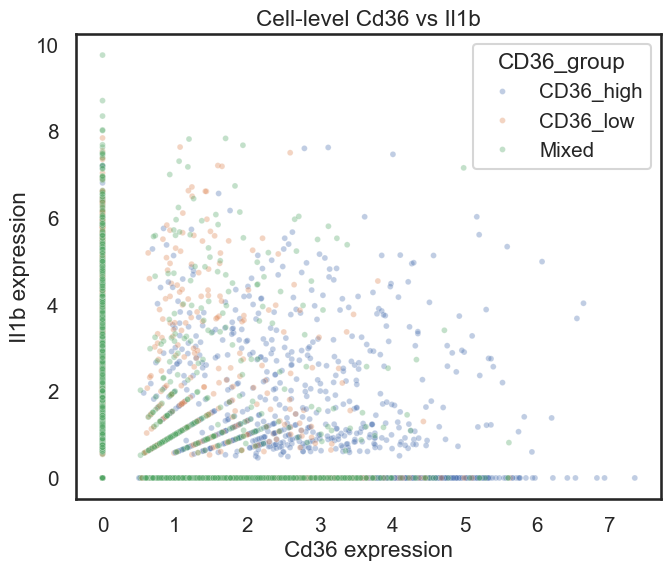

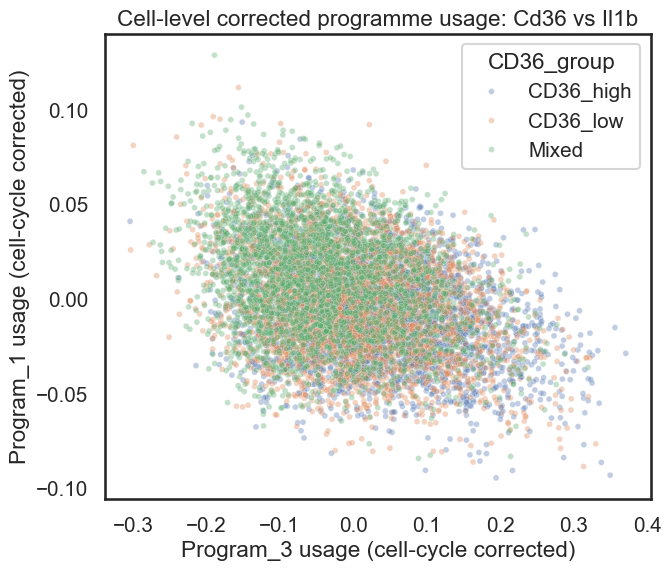

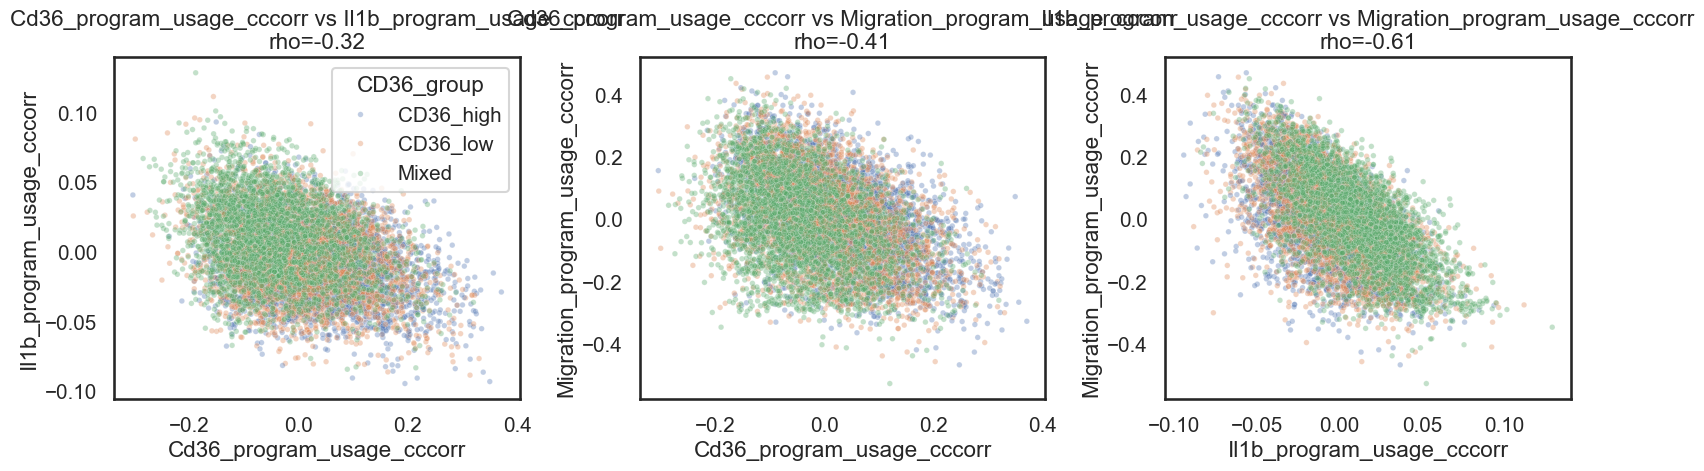

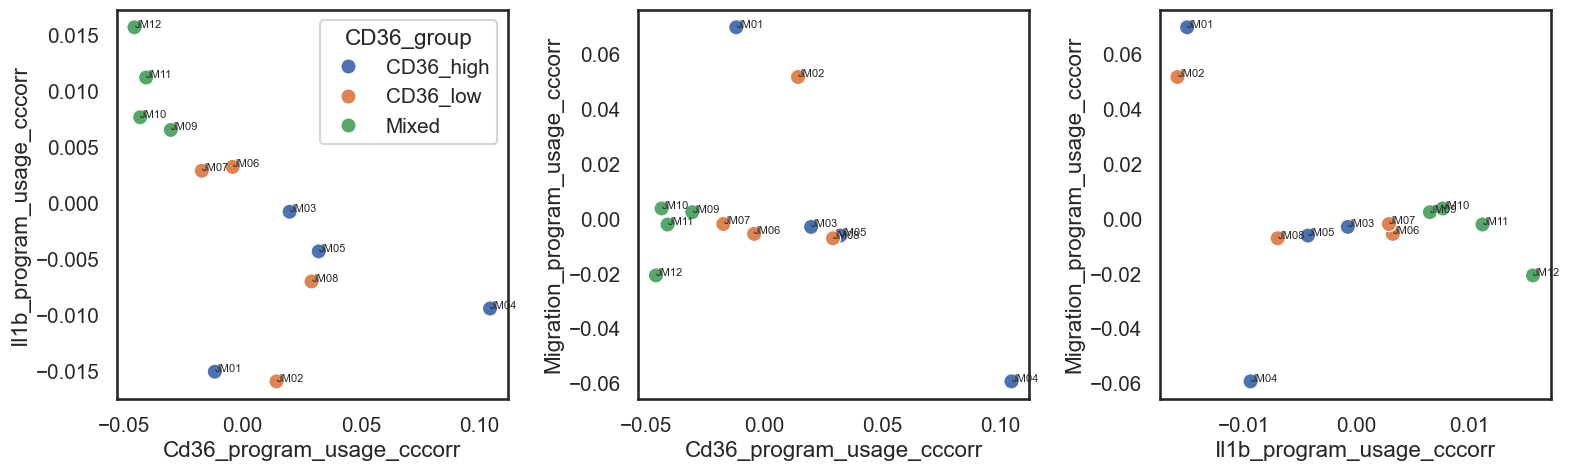

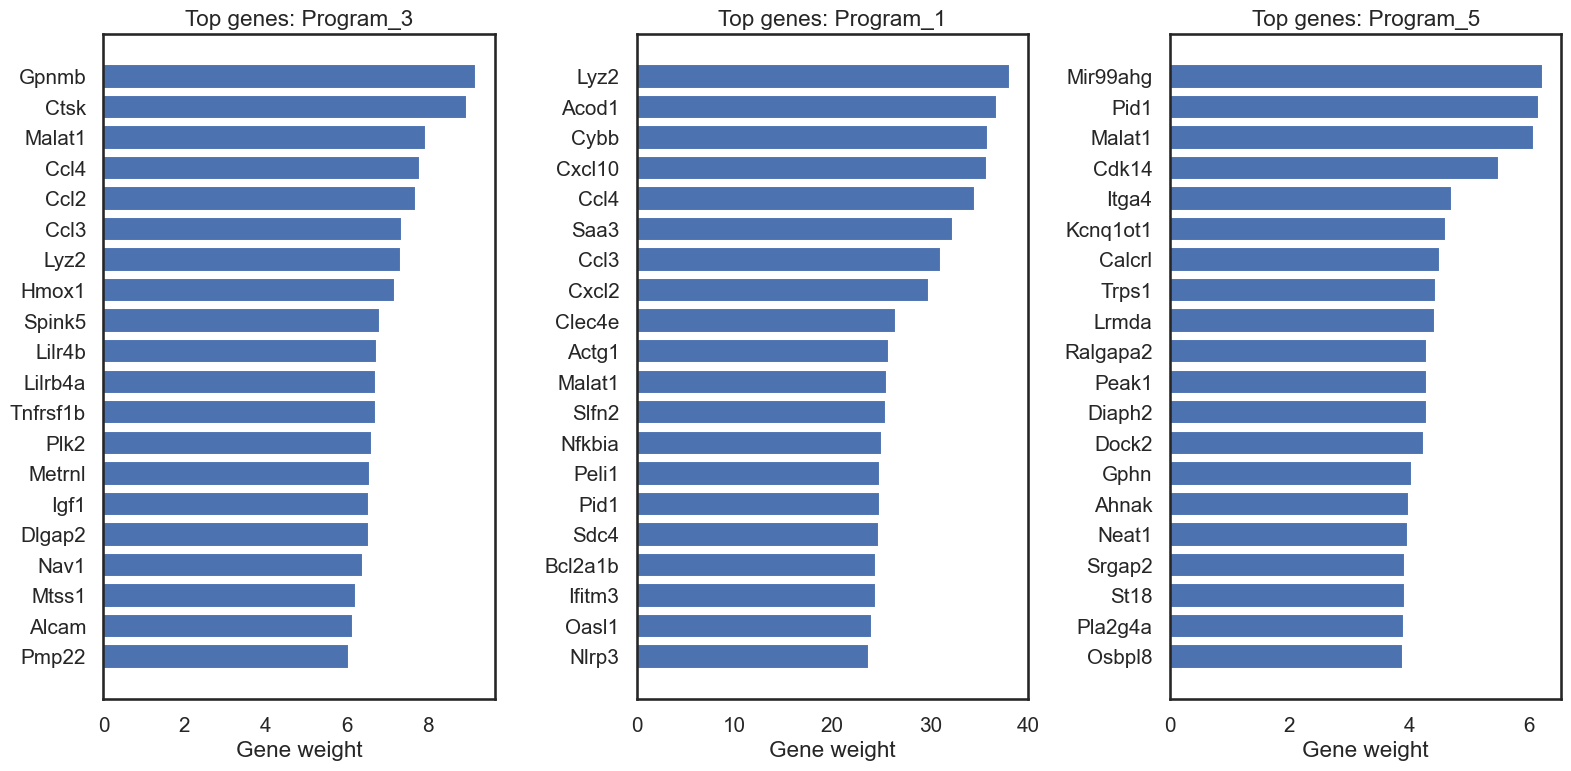

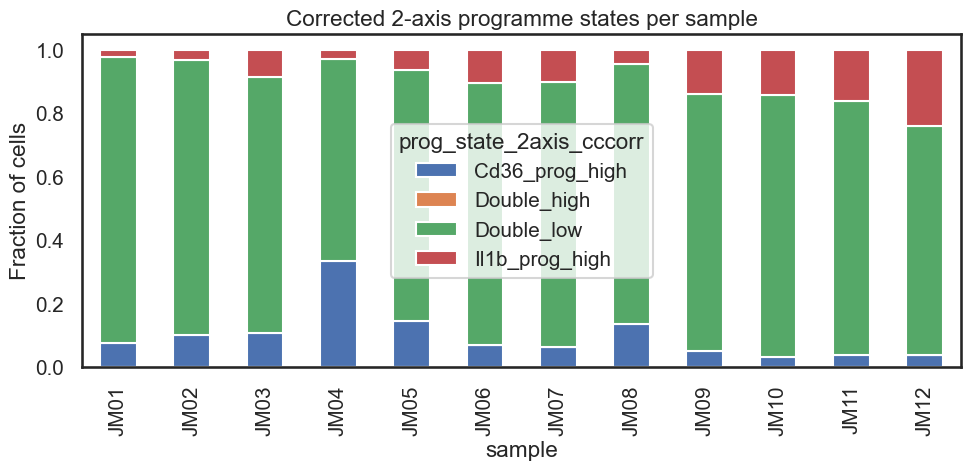

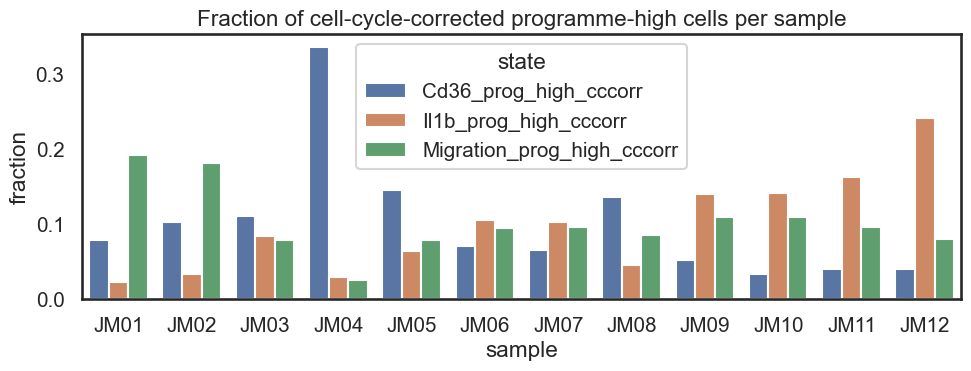

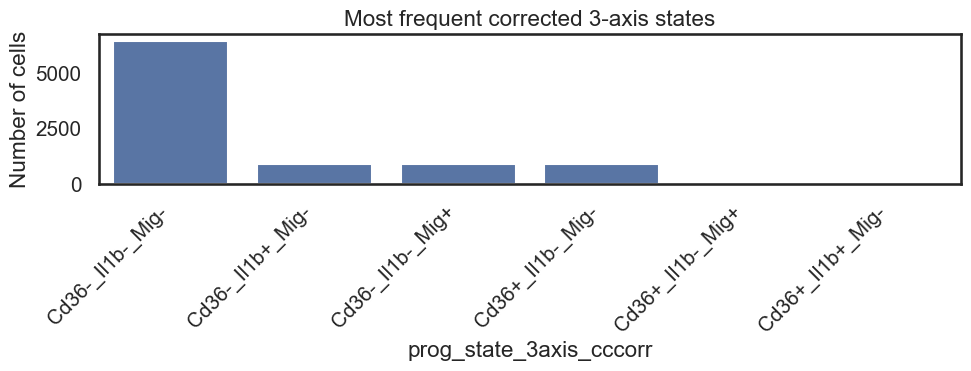


Saved objects:
- spectra
- usage
- usage_resid
- plot_df
- sample_means
- sample_state_fractions_2axis
- sample_prog_high_frac
- cd36_program = Program_3
- il1b_program = Program_1
- migration_program = Program_5


In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy.stats import spearmanr
from sklearn.decomposition import NMF

# =========================================================
# INPUTS
# =========================================================
df = df_filtered.copy()

# anchor genes
cd36_gene = "Cd36"
il1b_gene = "Il1b"


#k=6
cd36_panel = ["Cd36", "Gpnmb", "Ctsk", "Hmox1", "Igf1", "Trem2", "Metrnl", "Plk2"]
il1b_panel = ["Il1b","Acod1", "Cxcl2", "Cybb", "Nlrp3", "Tnf", "Nfkbia", "Cxcl10"]

migration_panel = ["Dock2", "Diaph2", "Itga4", "Calcrl", "Ahnak", "Peak1", "Ralgapa2", "Gphn", "Pla2g4a", "Cdk14"]

# sample groups
high_clones = ["JM01", "JM03", "JM04", "JM05"]
low_clones  = ["JM02", "JM06", "JM07", "JM08"]
mixed_clones = ["JM09", "JM10", "JM11", "JM12"]

# analysis settings
n_top_variable_genes = 2000
nmf_k = 6
random_state = 0
max_iter = 1000
min_cells_detected = 3
high_quantile = 0.90

# based on previous annotation:
# Program_2 = S phase
# Program_4 = G2/M
# Program_6 = Early entry
#cell_cycle_programs = ["Program_2", "Program_4"]

cell_cycle_programs = ["Program_2", "Program_4", "Program_6"] #regress all cell cycle related

# =========================================================
# HELPER FUNCTIONS
# =========================================================
def assign_group(sample):
    if sample in high_clones:
        return "CD36_high"
    elif sample in low_clones:
        return "CD36_low"
    elif sample in mixed_clones:
        return "Mixed"
    else:
        return np.nan

def top_program_genes(spectra, program_name, top_n=20):
    return spectra.loc[program_name].sort_values(ascending=False).head(top_n)

def score_program_against_panel(spectra, panel, method="mean_rank"):
    panel_present = [g for g in panel if g in spectra.columns]
    if len(panel_present) == 0:
        raise ValueError(f"None of the panel genes were found: {panel}")

    if method == "mean_weight":
        scores = spectra[panel_present].mean(axis=1)

    elif method == "mean_rank":
        rank_scores = []
        n_genes = spectra.shape[1]

        for prog in spectra.index:
            s = spectra.loc[prog]
            ranks = s.rank(ascending=False, method="average")
            norm_rank = 1 - (ranks - 1) / (n_genes - 1)
            rank_scores.append(norm_rank[panel_present].mean())

        scores = pd.Series(rank_scores, index=spectra.index)

    else:
        raise ValueError("method must be 'mean_weight' or 'mean_rank'")

    return scores.sort_values(ascending=False)

def assign_prog_state_2axis(row):
    if row["Cd36_prog_high_cccorr"] and row["Il1b_prog_high_cccorr"]:
        return "Double_high"
    elif row["Cd36_prog_high_cccorr"]:
        return "Cd36_prog_high"
    elif row["Il1b_prog_high_cccorr"]:
        return "Il1b_prog_high"
    else:
        return "Double_low"

def assign_prog_state_3axis(row):
    return (
        ("Cd36+" if row["Cd36_prog_high_cccorr"] else "Cd36-") + "_" +
        ("Il1b+" if row["Il1b_prog_high_cccorr"] else "Il1b-") + "_" +
        ("Mig+" if row["Migration_prog_high_cccorr"] else "Mig-")
    )

# =========================================================
# CHECKS
# =========================================================
if "Symbol" not in df.columns:
    raise ValueError("Column 'Symbol' not found.")

sample_mask = df.columns.astype(str).str.startswith("JM")
if sample_mask.sum() == 0:
    raise ValueError("No JM columns found.")

# =========================================================
# BUILD EXPRESSION MATRIX SAFELY
# =========================================================
sample_labels = df.columns[sample_mask].astype(str).to_numpy()
cell_ids = [f"cell_{i:05d}" for i in range(len(sample_labels))]

symbol_idx = df.columns.get_loc("Symbol")
jm_idx = np.where(sample_mask)[0]
keep_idx = np.r_[symbol_idx, jm_idx]

expr = df.iloc[:, keep_idx].copy()
expr.columns = ["Symbol"] + cell_ids
expr["Symbol"] = expr["Symbol"].astype(str)

expr_numeric = expr.iloc[:, 1:].apply(pd.to_numeric, errors="coerce")

gene_meta = pd.DataFrame({
    "Symbol": expr["Symbol"].values,
    "mean_expr": expr_numeric.mean(axis=1).values
})

order = np.lexsort((-gene_meta["mean_expr"].to_numpy(), gene_meta["Symbol"].to_numpy()))
expr_sorted = expr.iloc[order].copy()
expr_sorted = expr_sorted.drop_duplicates(subset="Symbol", keep="first")

expr = expr_sorted.set_index("Symbol")
expr = expr.fillna(0).astype(np.float32)

# =========================================================
# CELL METADATA
# =========================================================
cell_meta = pd.DataFrame({
    "cell_id": cell_ids,
    "sample": sample_labels
}).set_index("cell_id")

cell_meta["CD36_group"] = cell_meta["sample"].apply(assign_group)

keep_cells = cell_meta["CD36_group"].notna()
cell_meta = cell_meta.loc[keep_cells].copy()
expr = expr.loc[:, cell_meta.index].copy()

print("Expression matrix shape after setup:", expr.shape)
print(cell_meta.head())

# =========================================================
# FILTER LOWLY EXPRESSED GENES
# =========================================================
min_cells = max(min_cells_detected, int(0.01 * expr.shape[1]))
gene_detected_cells = (expr > 0).sum(axis=1)
expr = expr.loc[gene_detected_cells >= min_cells].copy()

print(f"Min cells threshold: {min_cells}")
print(f"Genes after expression filter: {expr.shape[0]}")

# =========================================================
# SELECT VARIABLE GENES
# =========================================================
gene_var = expr.var(axis=1)
top_var_genes = gene_var.sort_values(ascending=False).head(
    min(n_top_variable_genes, len(gene_var))
).index

expr_var = expr.loc[top_var_genes].copy()

for g in sorted(set(cd36_panel + il1b_panel + migration_panel)):
    if g in expr.index and g not in expr_var.index:
        expr_var = pd.concat([expr_var, expr.loc[[g]]], axis=0)

expr_var = expr_var[~expr_var.index.duplicated(keep="first")]
expr_var = expr_var.astype(np.float32)

print("Matrix for NMF:", expr_var.shape[0], "genes x", expr_var.shape[1], "cells")

# =========================================================
# PREPARE MATRIX FOR NMF
# IMPORTANT: NO RE-NORMALISATION OR RE-LOGGING
# input is already normalized/log-transformed upstream
# =========================================================
X = expr_var.T.copy().astype(np.float32)
X_log = X.copy()

# =========================================================
# RUN NMF
# =========================================================
nmf = NMF(
    n_components=nmf_k,
    init="nndsvda",
    random_state=random_state,
    max_iter=max_iter
)

W = nmf.fit_transform(X_log)
H = nmf.components_

usage = pd.DataFrame(
    W,
    index=X_log.index,
    columns=[f"Program_{i+1}" for i in range(nmf_k)]
)

spectra = pd.DataFrame(
    H,
    index=[f"Program_{i+1}" for i in range(nmf_k)],
    columns=X_log.columns
)

# =========================================================
# ASSIGN PROGRAMMES USING PANELS
# =========================================================
cd36_prog_scores = score_program_against_panel(spectra, cd36_panel, method="mean_rank")
il1b_prog_scores = score_program_against_panel(spectra, il1b_panel, method="mean_rank")
migration_prog_scores = score_program_against_panel(spectra, migration_panel, method="mean_rank")

cd36_program = cd36_prog_scores.idxmax()
il1b_program = il1b_prog_scores.idxmax()
migration_program = migration_prog_scores.idxmax()

print("\n=== Cd36-panel programme scores ===")
print(cd36_prog_scores)
print("\n=== Il1b-panel programme scores ===")
print(il1b_prog_scores)
print("\n=== Migration-panel programme scores ===")
print(migration_prog_scores)

print(f"\nFinal Cd36-like programme: {cd36_program}")
print(f"Final Il1b-like programme: {il1b_program}")
print(f"Final Migration-like programme: {migration_program}")

# =========================================================
# CELL-CYCLE REGRESSION
# regress Program_2 and Program_4 out of non-cell-cycle programmes
# =========================================================
missing_cc = [p for p in cell_cycle_programs if p not in usage.columns]
if len(missing_cc) > 0:
    raise ValueError(f"Missing cell-cycle programmes in usage: {missing_cc}")

usage_resid = usage.copy()

for prog in usage.columns:
    if prog in cell_cycle_programs:
        continue

    y = usage[prog].values
    X_cc = usage[cell_cycle_programs].copy()
    X_cc = sm.add_constant(X_cc)

    model = sm.OLS(y, X_cc).fit()
    usage_resid[prog] = model.resid

print("\nCell-cycle regression completed.")

# =========================================================
# BUILD CELL-LEVEL RESULTS TABLE
# =========================================================
plot_df = cell_meta.copy()

plot_df["Cd36"] = X_log[cd36_gene].reindex(plot_df.index).values if cd36_gene in X_log.columns else np.nan
plot_df["Il1b"] = X_log[il1b_gene].reindex(plot_df.index).values if il1b_gene in X_log.columns else np.nan

plot_df["Cd36_program_usage"] = usage.loc[plot_df.index, cd36_program]
plot_df["Il1b_program_usage"] = usage.loc[plot_df.index, il1b_program]
plot_df["Migration_program_usage"] = usage.loc[plot_df.index, migration_program]

plot_df["Cd36_program_usage_cccorr"] = usage_resid.loc[plot_df.index, cd36_program]
plot_df["Il1b_program_usage_cccorr"] = usage_resid.loc[plot_df.index, il1b_program]
plot_df["Migration_program_usage_cccorr"] = usage_resid.loc[plot_df.index, migration_program]

for g in sorted(set(cd36_panel + il1b_panel + migration_panel)):
    if g in X_log.columns and g not in plot_df.columns:
        plot_df[g] = X_log.loc[plot_df.index, g].values

# =========================================================
# DEFINE CORRECTED STATES
# =========================================================
cd36_thr_cc = plot_df["Cd36_program_usage_cccorr"].quantile(high_quantile)
il1b_thr_cc = plot_df["Il1b_program_usage_cccorr"].quantile(high_quantile)
mig_thr_cc = plot_df["Migration_program_usage_cccorr"].quantile(high_quantile)

plot_df["Cd36_prog_high_cccorr"] = plot_df["Cd36_program_usage_cccorr"] >= cd36_thr_cc
plot_df["Il1b_prog_high_cccorr"] = plot_df["Il1b_program_usage_cccorr"] >= il1b_thr_cc
plot_df["Migration_prog_high_cccorr"] = plot_df["Migration_program_usage_cccorr"] >= mig_thr_cc

plot_df["prog_state_2axis_cccorr"] = plot_df.apply(assign_prog_state_2axis, axis=1)
plot_df["prog_state_3axis_cccorr"] = plot_df.apply(assign_prog_state_3axis, axis=1)

print("\n2-axis corrected programme-state counts:")
print(plot_df["prog_state_2axis_cccorr"].value_counts())

print("\nTop 3-axis corrected states:")
print(plot_df["prog_state_3axis_cccorr"].value_counts().head(12))

# =========================================================
# SAMPLE-LEVEL SUMMARIES
# =========================================================
sample_means = (
    plot_df.groupby("sample", as_index=False)[[
        "Cd36",
        "Il1b",
        "Cd36_program_usage",
        "Il1b_program_usage",
        "Migration_program_usage",
        "Cd36_program_usage_cccorr",
        "Il1b_program_usage_cccorr",
        "Migration_program_usage_cccorr"
    ]].mean()
)
sample_means["CD36_group"] = sample_means["sample"].apply(assign_group)

sample_state_counts_2axis = (
    plot_df.groupby(["sample", "prog_state_2axis_cccorr"])
    .size()
    .unstack(fill_value=0)
)
sample_state_fractions_2axis = sample_state_counts_2axis.div(sample_state_counts_2axis.sum(axis=1), axis=0)

sample_prog_high_frac = (
    plot_df.groupby("sample")[[
        "Cd36_prog_high_cccorr",
        "Il1b_prog_high_cccorr",
        "Migration_prog_high_cccorr"
    ]]
    .mean()
    .reset_index()
)
sample_prog_high_frac["CD36_group"] = sample_prog_high_frac["sample"].apply(assign_group)

# =========================================================
# CORRELATIONS
# =========================================================
print("\n=== Overall correlations: corrected biological axes ===")
pairs = [
    ("Cd36_program_usage_cccorr", "Il1b_program_usage_cccorr"),
    ("Cd36_program_usage_cccorr", "Migration_program_usage_cccorr"),
    ("Il1b_program_usage_cccorr", "Migration_program_usage_cccorr")
]
for x, y in pairs:
    rho, p = spearmanr(plot_df[x], plot_df[y], nan_policy="omit")
    print(f"{x} vs {y}: rho = {rho:.4f}, p = {p:.4e}")

print("\n=== Sample-level correlations: corrected biological axes ===")
for x, y in pairs:
    rho, p = spearmanr(sample_means[x], sample_means[y], nan_policy="omit")
    print(f"{x} vs {y}: rho = {rho:.4f}, p = {p:.4e}")

print("\n=== Check residual correlation with cell-cycle programmes ===")
for prog in [cd36_program, il1b_program, migration_program]:
    if prog in cell_cycle_programs:
        continue
    for cc in cell_cycle_programs:
        rho_before, _ = spearmanr(usage[prog], usage[cc], nan_policy="omit")
        rho_after, _ = spearmanr(usage_resid[prog], usage[cc], nan_policy="omit")
        print(f"{prog} vs {cc}: before={rho_before:.4f}, after={rho_after:.4f}")

print("\n=== Corrected Cd36 programme correlations with panel genes ===")
for g in cd36_panel:
    if g in plot_df.columns:
        rho, p = spearmanr(plot_df["Cd36_program_usage_cccorr"], plot_df[g], nan_policy="omit")
        print(f"{g:12s} rho = {rho:.4f}, p = {p:.2e}")

print("\n=== Corrected Il1b programme correlations with panel genes ===")
for g in il1b_panel:
    if g in plot_df.columns:
        rho, p = spearmanr(plot_df["Il1b_program_usage_cccorr"], plot_df[g], nan_policy="omit")
        print(f"{g:12s} rho = {rho:.4f}, p = {p:.2e}")

print("\n=== Corrected Migration programme correlations with panel genes ===")
for g in migration_panel:
    if g in plot_df.columns:
        rho, p = spearmanr(plot_df["Migration_program_usage_cccorr"], plot_df[g], nan_policy="omit")
        print(f"{g:12s} rho = {rho:.4f}, p = {p:.2e}")

# =========================================================
# TOP GENES FOR ALL PROGRAMMES
# =========================================================
for prog in spectra.index:
    print(f"\n=== {prog} ===")
    print(top_program_genes(spectra, prog, 20))

# =========================================================
# PLOTS
# =========================================================

# 1. Raw anchor genes
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=plot_df,
    x="Cd36",
    y="Il1b",
    hue="CD36_group",
    alpha=0.35,
    s=18
)
plt.title("Cell-level Cd36 vs Il1b")
plt.xlabel("Cd36 expression")
plt.ylabel("Il1b expression")
plt.tight_layout()
plt.show()

# 2. Corrected Cd36 vs Il1b
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=plot_df,
    x="Cd36_program_usage_cccorr",
    y="Il1b_program_usage_cccorr",
    hue="CD36_group",
    alpha=0.35,
    s=18
)
plt.title("Cell-level corrected programme usage: Cd36 vs Il1b")
plt.xlabel(f"{cd36_program} usage (cell-cycle corrected)")
plt.ylabel(f"{il1b_program} usage (cell-cycle corrected)")
plt.tight_layout()
plt.show()

# 3. Pairwise corrected biological axes
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pair_defs = [
    ("Cd36_program_usage_cccorr", "Il1b_program_usage_cccorr"),
    ("Cd36_program_usage_cccorr", "Migration_program_usage_cccorr"),
    ("Il1b_program_usage_cccorr", "Migration_program_usage_cccorr"),
]

for i, (ax, (x, y)) in enumerate(zip(axes, pair_defs)):
    sns.scatterplot(
        data=plot_df,
        x=x,
        y=y,
        hue="CD36_group",
        alpha=0.35,
        s=16,
        ax=ax,
        legend=(i == 0)
    )
    rho, _ = spearmanr(plot_df[x], plot_df[y], nan_policy="omit")
    ax.set_title(f"{x} vs {y}\nrho={rho:.2f}")
    if i > 0 and ax.get_legend() is not None:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()

# 4. Sample-level corrected biological axes
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (ax, (x, y)) in enumerate(zip(axes, pair_defs)):
    sns.scatterplot(
        data=sample_means,
        x=x,
        y=y,
        hue="CD36_group",
        s=120,
        ax=ax,
        legend=(i == 0)
    )
    for _, row in sample_means.iterrows():
        ax.text(row[x], row[y], row["sample"], fontsize=8, ha="left")
    if i > 0 and ax.get_legend() is not None:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()

# 5. Top genes for Cd36 / Il1b / Migration programmes
fig, axes = plt.subplots(1, 3, figsize=(16, 8))

for ax, prog in zip(axes, [cd36_program, il1b_program, migration_program]):
    top = top_program_genes(spectra, prog, 20).sort_values()
    ax.barh(top.index, top.values)
    ax.set_title(f"Top genes: {prog}")
    ax.set_xlabel("Gene weight")

plt.tight_layout()
plt.show()

# 6. Corrected 2-axis state fractions per sample
sample_state_fractions_2axis.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)
plt.ylabel("Fraction of cells")
plt.title("Corrected 2-axis programme states per sample")
plt.tight_layout()
plt.show()

# 7. Fraction of programme-high cells per sample
sample_prog_high_frac_m = sample_prog_high_frac.melt(
    id_vars=["sample", "CD36_group"],
    value_vars=[
        "Cd36_prog_high_cccorr",
        "Il1b_prog_high_cccorr",
        "Migration_prog_high_cccorr"
    ],
    var_name="state",
    value_name="fraction"
)

plt.figure(figsize=(10, 4))
sns.barplot(
    data=sample_prog_high_frac_m,
    x="sample",
    y="fraction",
    hue="state"
)
plt.title("Fraction of cell-cycle-corrected programme-high cells per sample")
plt.tight_layout()
plt.show()

# 8. 3-axis state counts
state3_counts = plot_df["prog_state_3axis_cccorr"].value_counts().head(12)

plt.figure(figsize=(10, 4))
sns.barplot(
    x=state3_counts.index,
    y=state3_counts.values
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of cells")
plt.title("Most frequent corrected 3-axis states")
plt.tight_layout()
plt.show()

# =========================================================
# OUTPUT OBJECTS
# =========================================================
print("\nSaved objects:")
print("- spectra")
print("- usage")
print("- usage_resid")
print("- plot_df")
print("- sample_means")
print("- sample_state_fractions_2axis")
print("- sample_prog_high_frac")
print(f"- cd36_program = {cd36_program}")
print(f"- il1b_program = {il1b_program}")
print(f"- migration_program = {migration_program}")

To identify transcriptional programmes underlying macrophage heterogeneity, we applied non-negative matrix factorization (NMF) to single-cell RNA-seq data. This analysis revealed three dominant and biologically interpretable programmes: a Cd36-associated remodelling programme, an Il1b-associated inflammatory programme, and a cytoskeletal/motility programme.

Importantly, these programmes were largely mutually exclusive at the single-cell level. Cells with high Cd36 programme usage exhibited low Il1b and migration activity, while Il1b-high cells showed reduced Cd36 and migration signals. A third population of cells displayed high migration programme activity but low Cd36 and Il1b expression, suggesting a distinct motile or surveillance state.

These relationships were further reinforced at the population level, where clonal samples segregated along the Cd36–Il1b axis. Together, these results define a three-axis transcriptional landscape in which macrophages occupy discrete functional states corresponding to remodelling, inflammatory, or migratory phenotypes.

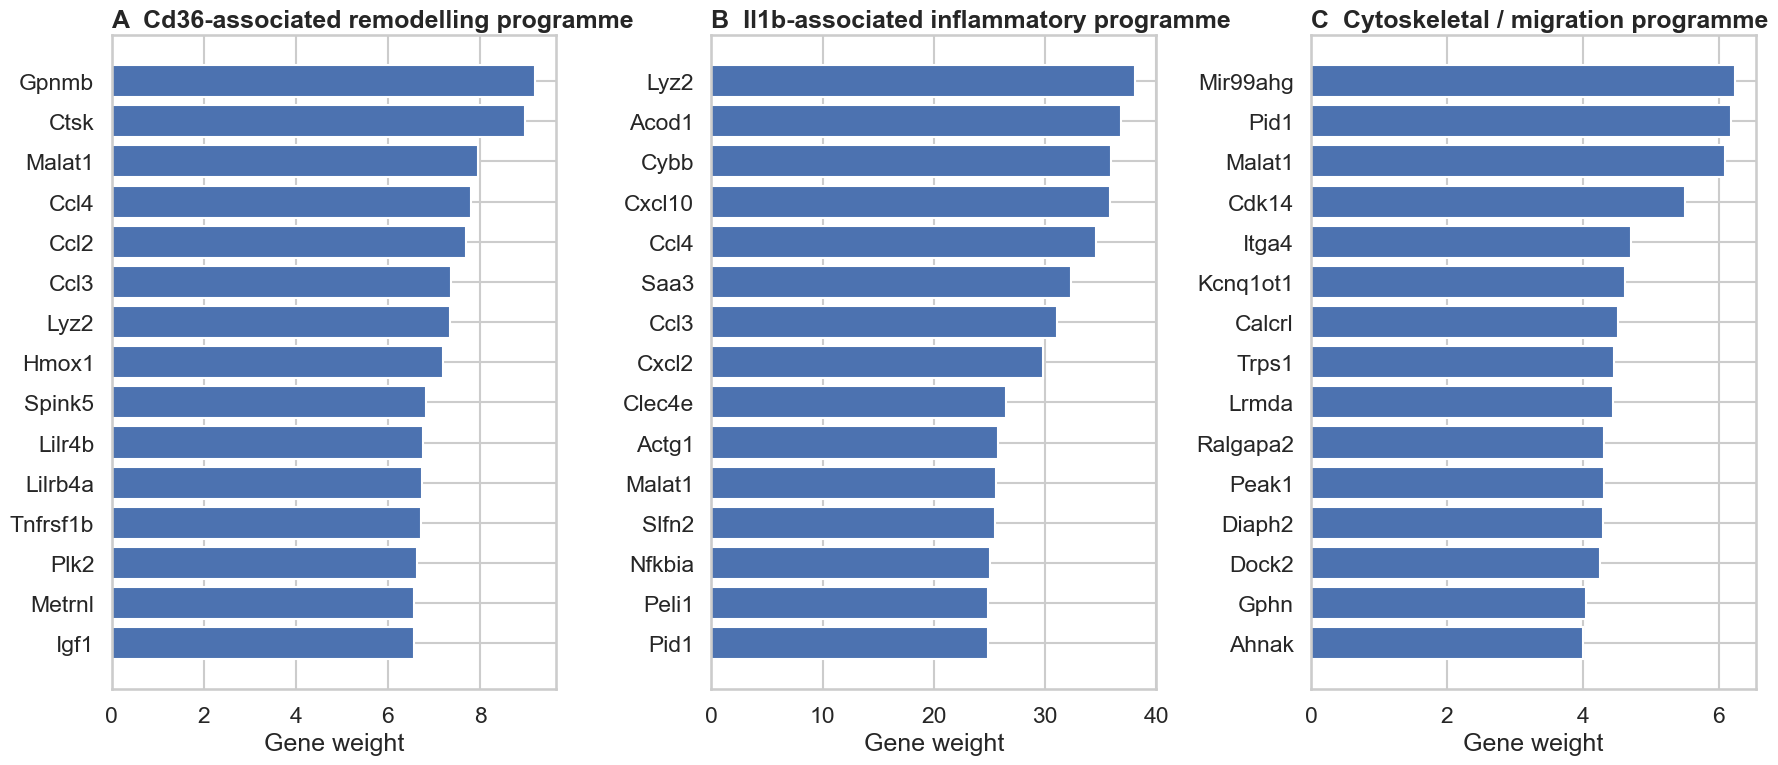

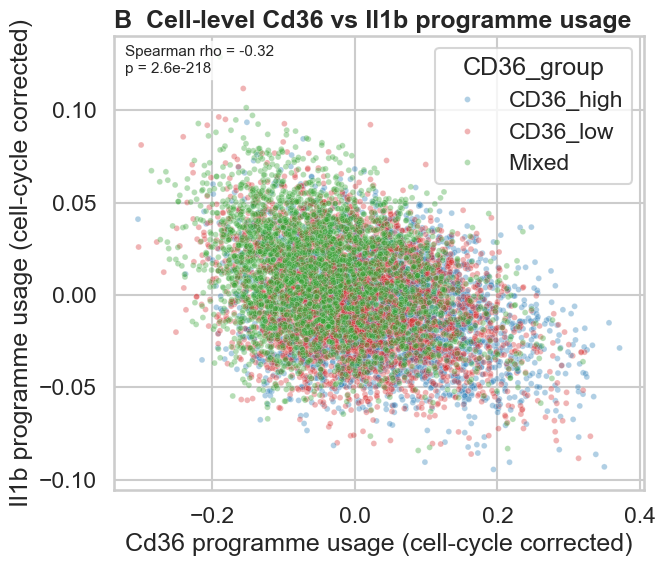

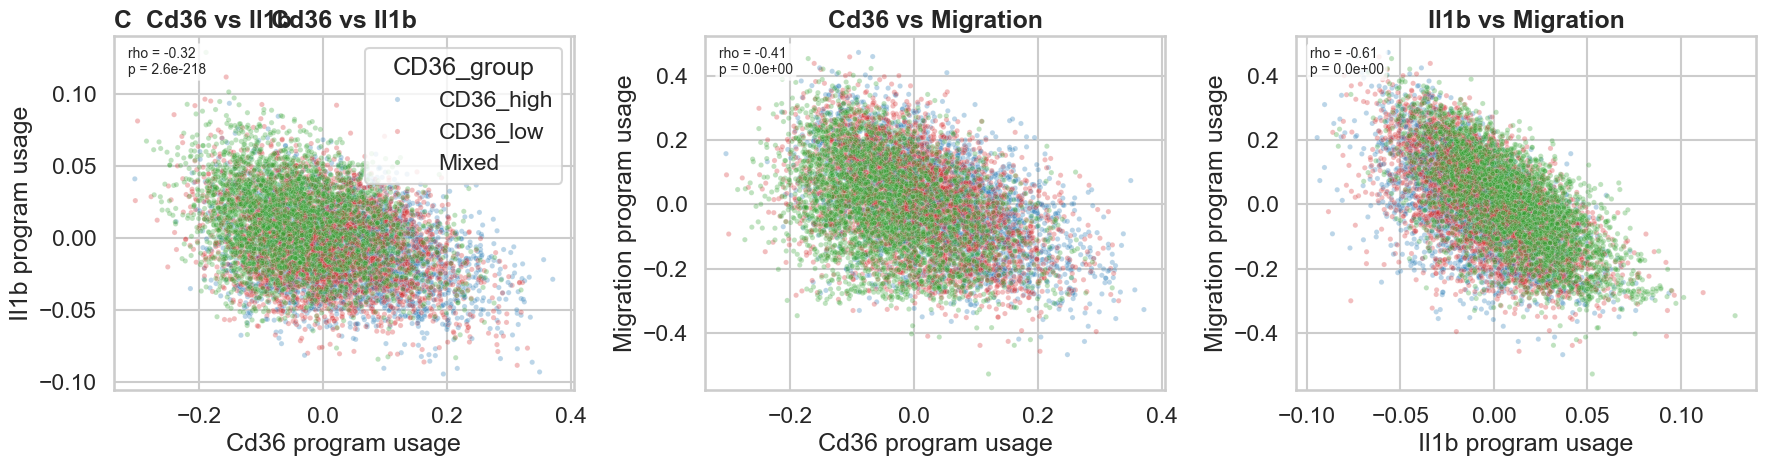

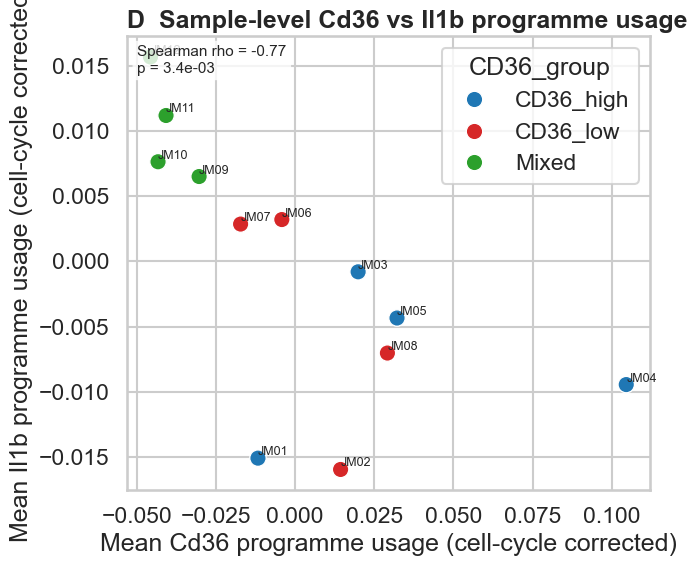

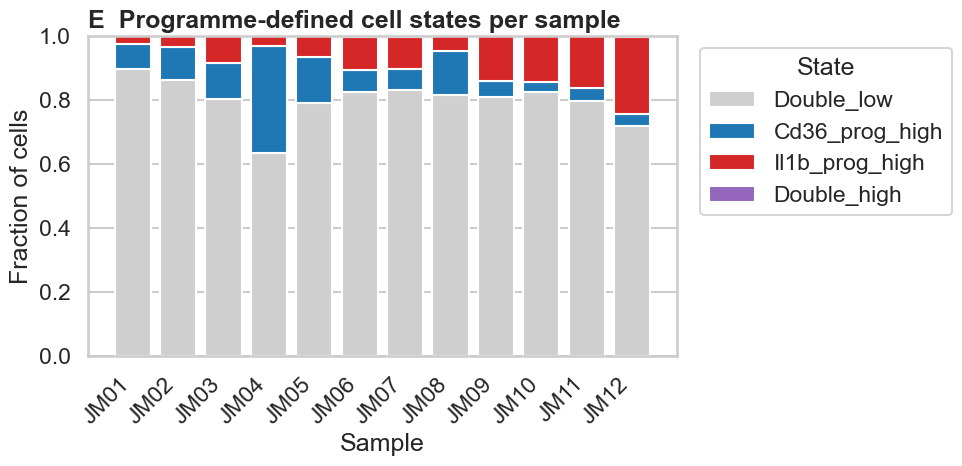

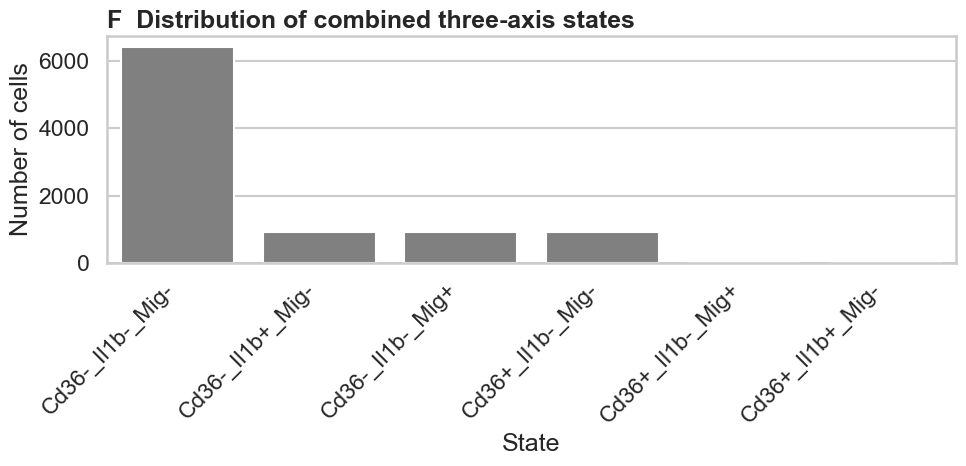

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import spearmanr

# ---------------------------------------------------------
# SETTINGS
# ---------------------------------------------------------
top_n = 15
sns.set(style="whitegrid", context="talk")

# helpful colors
group_palette = {
    "CD36_high": "#1f77b4",
    "CD36_low": "#d62728",
    "Mixed": "#2ca02c"
}

state_palette_2axis = {
    "Double_low": "#cfcfcf",
    "Cd36_prog_high": "#1f77b4",
    "Il1b_prog_high": "#d62728",
    "Double_high": "#9467bd"
}

# ---------------------------------------------------------
# helper
# ---------------------------------------------------------
def get_top_genes_df(spectra, program_name, top_n=15, label=None):
    s = spectra.loc[program_name].sort_values(ascending=False).head(top_n)
    out = pd.DataFrame({
        "gene": s.index,
        "weight": s.values,
        "program": label if label is not None else program_name
    })
    return out

# ---------------------------------------------------------
# PANEL A
# Top genes for Cd36 / Il1b / Migration programmes
# ---------------------------------------------------------
cd36_top_df = get_top_genes_df(spectra, cd36_program, top_n=top_n, label="Cd36 programme")
il1b_top_df = get_top_genes_df(spectra, il1b_program, top_n=top_n, label="Il1b programme")
mig_top_df  = get_top_genes_df(spectra, migration_program, top_n=top_n, label="Migration programme")

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for ax, df_top, title in zip(
    axes,
    [cd36_top_df, il1b_top_df, mig_top_df],
    ["A  Cd36-associated remodelling programme",
     "B  Il1b-associated inflammatory programme",
     "C  Cytoskeletal / migration programme"]
):
    df_plot = df_top.sort_values("weight", ascending=True)
    ax.barh(df_plot["gene"], df_plot["weight"])
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xlabel("Gene weight")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PANEL B
# Cell-level corrected Cd36 vs Il1b
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))

sns.scatterplot(
    data=plot_df,
    x="Cd36_program_usage_cccorr",
    y="Il1b_program_usage_cccorr",
    hue="CD36_group",
    palette=group_palette,
    alpha=0.35,
    s=18,
    ax=ax
)

rho, p = spearmanr(
    plot_df["Cd36_program_usage_cccorr"],
    plot_df["Il1b_program_usage_cccorr"],
    nan_policy="omit"
)

ax.set_title("B  Cell-level Cd36 vs Il1b programme usage", loc="left", fontweight="bold")
ax.set_xlabel("Cd36 programme usage (cell-cycle corrected)")
ax.set_ylabel("Il1b programme usage (cell-cycle corrected)")
ax.text(
    0.02, 0.98,
    f"Spearman rho = {rho:.2f}\np = {p:.1e}",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor="none")
)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PANEL C
# Pairwise corrected programme relationships
# ---------------------------------------------------------
pairs = [
    ("Cd36_program_usage_cccorr", "Il1b_program_usage_cccorr", "Cd36 vs Il1b"),
    ("Cd36_program_usage_cccorr", "Migration_program_usage_cccorr", "Cd36 vs Migration"),
    ("Il1b_program_usage_cccorr", "Migration_program_usage_cccorr", "Il1b vs Migration"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (x, y, title) in zip(axes, pairs):
    sns.scatterplot(
        data=plot_df,
        x=x,
        y=y,
        hue="CD36_group",
        palette=group_palette,
        alpha=0.3,
        s=14,
        ax=ax,
        legend=(ax == axes[0])
    )
    rho, p = spearmanr(plot_df[x], plot_df[y], nan_policy="omit")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(x.replace("_cccorr", "").replace("_", " "))
    ax.set_ylabel(y.replace("_cccorr", "").replace("_", " "))
    ax.text(
        0.03, 0.97,
        f"rho = {rho:.2f}\np = {p:.1e}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, edgecolor="none")
    )

axes[0].set_title("C  Cd36 vs Il1b", loc="left", fontweight="bold")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PANEL D
# Sample-level corrected Cd36 vs Il1b
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))

sns.scatterplot(
    data=sample_means,
    x="Cd36_program_usage_cccorr",
    y="Il1b_program_usage_cccorr",
    hue="CD36_group",
    palette=group_palette,
    s=140,
    ax=ax
)

for _, row in sample_means.iterrows():
    ax.text(
        row["Cd36_program_usage_cccorr"],
        row["Il1b_program_usage_cccorr"],
        row["sample"],
        fontsize=9,
        ha="left",
        va="bottom"
    )

rho, p = spearmanr(
    sample_means["Cd36_program_usage_cccorr"],
    sample_means["Il1b_program_usage_cccorr"],
    nan_policy="omit"
)

ax.set_title("D  Sample-level Cd36 vs Il1b programme usage", loc="left", fontweight="bold")
ax.set_xlabel("Mean Cd36 programme usage (cell-cycle corrected)")
ax.set_ylabel("Mean Il1b programme usage (cell-cycle corrected)")
ax.text(
    0.02, 0.98,
    f"Spearman rho = {rho:.2f}\np = {p:.1e}",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor="none")
)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PANEL E
# Stacked barplot of corrected 2-axis states per sample
# expects sample_state_fractions_2axis from previous script
# ---------------------------------------------------------
state_order = ["Double_low", "Cd36_prog_high", "Il1b_prog_high", "Double_high"]

state_frac_plot = sample_state_fractions_2axis.copy()
for s in state_order:
    if s not in state_frac_plot.columns:
        state_frac_plot[s] = 0.0
state_frac_plot = state_frac_plot[state_order]

fig, ax = plt.subplots(figsize=(10, 5))
bottom = None

for state in state_order:
    vals = state_frac_plot[state].values
    ax.bar(
        state_frac_plot.index,
        vals,
        bottom=bottom,
        label=state,
        color=state_palette_2axis.get(state, None)
    )
    bottom = vals if bottom is None else bottom + vals

ax.set_title("E  Programme-defined cell states per sample", loc="left", fontweight="bold")
ax.set_ylabel("Fraction of cells")
ax.set_xlabel("Sample")
ax.legend(title="State", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PANEL F
# Corrected 3-axis state distribution
# ---------------------------------------------------------
state3_counts = (
    plot_df["prog_state_3axis_cccorr"]
    .value_counts()
    .reset_index()
)
state3_counts.columns = ["state", "count"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=state3_counts,
    x="state",
    y="count",
    color="0.5",
    ax=ax
)

ax.set_title("F  Distribution of combined three-axis states", loc="left", fontweight="bold")
ax.set_xlabel("State")
ax.set_ylabel("Number of cells")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()